In [27]:
import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["PYTORCH_USE_CUDA_DSA"] = "1"
import numpy as np
import torch
import yaml
import pickle as pk
# autoreload modules
%load_ext autoreload
%autoreload 2

import matplotlib
%matplotlib inline
import matplotlib.pyplot as pl
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib

import matplotlib.pyplot as pl
pl.rc('text', usetex=False)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline

pl.rcParams['figure.dpi'] = 250

%load_ext Cython



        


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [2]:
import readfof
import sys, os
import numpy as np
import pickle as pk 
# from nbodykit.lab import *
import h5py as h5
import numpy as np
import Pk_library as PKL
import MAS_library as MASL
import yaml
# import galactic_wavelets as gw




In [3]:
# from test_ddp_PM_Mmin_13p0_nv64 import *
# from test_ddp_PM_Mmin_13p0_nv64_nemb_96 import *
from train_dtai import *




In [4]:
# checkpoint = torch.load('/mnt/home/spandey/ceph/GOTHAM/model_checkpoints/camels/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_16_iter_800.pt')
# print(checkpoint.keys())



In [5]:
dev = torch.device("cuda")
# checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_32_iter_900.pt')
# checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_32.pt')
checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_64.pt')
HaloConfig = checkpoint['config']
print(checkpoint['best_val_loss'])
learning_rate = 5e-4
model = HaloDecoderModel(HaloConfig).to(dev)
# if rank == 0: print(f"Init model and loaded to GPU", flush=True)            
# model.to(device).bfloat16()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_96_nembed_64_CORRMASK_NOFLASH_FINAL.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_64_nembed_64_Mmin_13p0.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_64_nembed_96_Mmin_13p0.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/CHARFORMER/model_checkpoints/model_encdec_ddp_PM_isim_012_nvocab_64_nembed_64_Mmin_13p5.pt')
# checkpoint = torch.load('/mnt/home/spandey/ceph/GOTHAM/model_checkpoints/camels/model_encdec_ddp_PM_nvocab_64_nembed_64_nrandsubsel_8_iter_1000.pt')
model.load_state_dict(checkpoint['model'])
model.eval()
print()
model = model.bfloat16()




/tmp/ipykernel_284585/3370681151.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/projects/bdne/spandey3/GOTHAM/model_checkpoints/camels_photo/m

tensor(1.8230)
Using flash:  False
Using flash:  False
Using flash:  False
Using flash:  False
Using flash:  False
Using flash:  False
number of parameters: 1.78M



In [6]:
params_all = np.loadtxt('/projects/bdne/spandey3/GOTHAM/prep_data/camels_tng_LH_params.txt', usecols=range(1, 7))



In [7]:
# isim_fid_array = np.arange(7, 11)
saved_all = {}
# isim_fid_array = np.arange(990, 1000)
isim_fid_array = np.arange(990, 1000)
# isim_fid = 6
for isim_fid in isim_fid_array:

    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH'
    df = pk.load(open(f'{sdir}/subhalo_density3Dgrid_32_isim_{isim_fid}_nrandsubsel_512_nvocab64_lgMmin_8.pkl','rb'))
    delta_box_all_squeezed_0 = df['delta_box_all_squeezed']

    sdir = '/work/hdd/bdne/spandey3/camels_tng/gotham_data/LH/wSDSS_photometry'
    df = pk.load(open(f'{sdir}/subhalo_WITHOUT_density3Dgrid_32_isim_{isim_fid}_nrandsubsel_512_nvocab64_wSDSS_photometry.pkl','rb'))    
    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
    # dfhalo_ngp_wxyzM_0 = df['dfhalo_ngp_wxyzM']
    # Nhalos_truth_0 = df['Nhalos_truth']
    param_0 = params_all[isim_fid][None, :]
    param_0 = np.repeat(param_0, len(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0), axis=0)

    grid = 8
    shift_x_all, shift_y_all, shift_z_all = np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid))
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                shift_x_all[jx, jy, jz] = jx
                shift_y_all[jx, jy, jz] = jy
                shift_z_all[jx, jy, jz] = jz

    shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed = shift_x_all.flatten(), shift_y_all.flatten(), shift_z_all.flatten()
    shift_all_squeezed = np.vstack([shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed]).T


    n1 = 8**3
    test_data_halos = dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0[:n1]

    test_data_dm = delta_box_all_squeezed_0[:n1]
    params_test = param_0[:n1]

    x = torch.tensor(test_data_halos[:, :-1])
    y = torch.tensor(test_data_halos[:, 1:])
    dm = torch.tensor(test_data_dm)
    mask_test_orig = x != 1
    mask_test = torch.logical_not(mask_test_orig)
    masked_logits = torch.zeros(mask_test.shape)
    mask_test_final = masked_logits.masked_fill(mask_test, float('-inf'))
    mask_test = mask_test_final[:,None,:]
    x, y = torch.tensor(x), torch.tensor(y)
    x_test = x.long()
    y_test = y.long()
    dm_test = dm.bfloat16()
    mask_test = torch.tensor(mask_test).bfloat16()
    params_test = torch.tensor(params_test).bfloat16()

    x_test_gpu = x_test.to(dev)
    y_test_gpu = y_test.to(dev)
    dm_test_gpu = dm_test.to(dev)
    mask_test_gpu = mask_test.to(dev)
    params_test_gpu = params_test.to(dev)


    def get_batch(split, ji=0, batch_size=None):
        if split == 'train':
            x = x_train_gpu
            y = y_train_gpu
            mask = mask_train_gpu
            dm = dm_train_gpu
            params = params_train_gpu

        elif split == 'val':
            x = x_val_gpu
            y = y_val_gpu
            mask = mask_val_gpu
            dm = dm_val_gpu
            params = params_val_gpu

        elif split == 'test':
            x = x_test_gpu
            y = y_test_gpu
            mask = mask_test_gpu
            dm = dm_test_gpu       
            params = params_test_gpu 

        if batch_size is not None:
            x = x[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            y = y[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            mask = mask[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            dm = dm[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
            params = params[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)

        return x, y, mask, dm, params

    batch_size = 8**3
    X_val, Y_val, MASK_val, DM_val, PARAMS = get_batch('test', 0, batch_size)
    DM_val = torch.moveaxis(DM_val, -1, 1)
    # DM_val.shape

    # DM_val_tosplit = DM_val.detach().cpu().to(torch.float16).numpy()[:batch_size, 0,:,:,:].reshape(batch_size, DM_val.shape[-1]**3)
    # DM_val_tosplit_mean = np.mean(DM_val_tosplit, axis=-1)

    # vlow = 0.00075
    # vmid = 0.0017

    # indlow = np.where(DM_val_tosplit_mean < vlow)[0]
    # indmid = np.where((DM_val_tosplit_mean >= vlow) & (DM_val_tosplit_mean < vmid))[0]
    # indhigh = np.where(DM_val_tosplit_mean >= vmid)[0]

    # print(len(indlow), len(indmid), len(indhigh))

    max_new_tokens = df['max_sentence_length']
    nvocab = df['nvocab_total'] - 3

    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    # bins_digitize.insert(0, -1)
    bins_digitize = np.insert(bins_digitize, 0, -1)


    start_token = 0
    pad_token = 1
    end_token = nvocab + 1
    space_token = nvocab + 2


    from tqdm import tqdm

    # end_token = 65
    # nvox_samp = 32**3
    # nbatches = 32
    fac = 1
    nvox_samp = batch_size
    nbatches = fac
    nvox_per_batch = nvox_samp // nbatches

    # idx_all = []
    # idx_all = torch.ones((nvox_samp, max_new_tokens), dtype=torch.long, device=dev)
    idx_all = np.ones((nvox_samp, max_new_tokens))
    
    for jb in tqdm(range(nbatches)):

        idx_inp = torch.zeros((nvox_per_batch, 1), dtype=torch.long, device=dev)

        DM_val_jb = DM_val[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...]

        param_jb = PARAMS[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...]

        new_samples_jb = np.ones((nvox_per_batch, max_new_tokens))

        ind_jb = np.arange(nvox_per_batch)

        new_samples_jb[:, 0] = idx_inp[:,0].cpu().detach().numpy()
        # idx = idx_inp
        for jt in range(1, max_new_tokens):
            if len(ind_jb) > 0:
                # crop idx to the last block_size tokens
                idx_cond = torch.tensor(new_samples_jb[ind_jb, :jt], dtype=torch.long, device=dev)
                # get the predictions
                logits, loss = model(idx_cond, DM_val_jb[ind_jb,...], params=param_jb[ind_jb,...])
                # focus only on the last time step
                logits = logits[:, -1, :] # becomes (B, C)
                # apply softmax to get probabilities
                probs = F.softmax(logits, dim=-1) # (B, C)
                # sample from the distribution
                idx_next = torch.multinomial(probs, num_samples=1).cpu().detach().numpy() # (B, 1)

                # append sampled index to the running sequence
                # if idx_next == end_token:
                    # break
                new_samples_jb[ind_jb, jt] = idx_next[:,0]
                ind_to_del = np.where(idx_next[:,0] == end_token)[0]
                # for jv in range(len(ind_jb)):
                    # if idx_next[jv, 0] == end_token:
                if len(ind_to_del) > 0:
                    ind_jb = np.delete(ind_jb, ind_to_del)


                


            # print(new_samples_jb[0,:])
            # idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        idx_all[jb*nvox_per_batch:(jb+1)*nvox_per_batch, :] = new_samples_jb
        # idx_all.append(idx)
    dm_mean_allvox = np.mean(np.array(DM_val[:,1,...].to(torch.float16).detach().cpu()), axis=(1,2,3))
    # Mmin_cut = 10**8
    # lgMin = np.log10(Mmin_cut)
    # lgMax = 11
    prop_min = np.array([25, 25, 25, 7.5])
    prop_max = np.array([30, 30, 30, 11])
    dim_pos = 3
    dim_prop = len(prop_min)    

    BoxSize = 25.
    grid = 8
    xmin = BoxSize/grid/2

    MAS     = 'NGP'  #mass-assigment scheme
    grid_Pk = 16
    threads = 10


    def get_prop_pos_Pk(X_val):
        Nhalo_all = []
        prop_all = []
        pos_all = []
        Pk_all = []
        dm_mean_all = []
    
        for jv in range(nvox_samp):
            try:
                idx = X_val[jv]
                idx = idx.cpu().numpy().flatten().astype(int)
            except:
                idx = X_val[jv].astype(int)
                idx = idx.flatten()
            
            idxe = np.where(idx == space_token)[0] + 1
            idx0 = np.where(idx == start_token)[0] + 1
            if len(idx0) == 1:
                if idx[idx0] != end_token:
                    Nhalo = len(idxe) + len(idx0)
                    Nhalo_all.append(Nhalo)
                    pos_halo = np.zeros((Nhalo, dim_pos))
                    pos_halo_unshifted = np.zeros((Nhalo, dim_pos))        
                    prophalo = np.zeros((Nhalo, dim_prop))
                    if Nhalo > 0:
                        try:
                            
                            for jh in range(Nhalo):
                                if jh == 0:
                                    for jx in range(dim_pos):
                                        shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                        pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx]] * 2 * xmin  + shift_coord        
                                        pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord
    
                                    for jx in range(dim_prop):
                                        prophalo[jh, jx] = bins_digitize[idx[idx0 + jx + dim_pos]] * (prop_max[jx] - prop_min[jx])  + prop_min[jx]
    
                                else:
                                    if Nhalo > 2:
                                        for jx in range(dim_pos):
                                            shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                            pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx]] * 2 * xmin  + shift_coord
                                            pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord
    
                                        for jx in range(dim_prop):
                                            prophalo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + dim_pos]] * (prop_max[jx] - prop_min[jx])  + prop_min[jx]
    
                                    else:
                                        for jx in range(dim_pos):
                                            shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                            pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord    
                                            pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord
    
                                        for jx in range(dim_prop):
                                            prophalo[jh, jx] = bins_digitize[idx[idxe + jx + dim_pos]] * (prop_max[jx] - prop_min[jx])  + prop_min[jx]
    
    
                            pos_all.append(pos_halo)
                            prop_all.append(prophalo)
                            dm_mean_all.append(dm_mean_allvox[jv] * np.ones(Nhalo))
    
                            if Nhalo > 5:
                                mesh = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                                MASL.MA(pos_halo_unshifted.astype(np.float32), mesh, 2*xmin, MAS)
                                mesh /= np.mean(mesh, dtype=np.float64);  mesh -= 1.0
                                Pk = PKL.Pk(mesh, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                                Pk_all.append(Pk.Pk[:,0])
                            else:
                                Pk_all.append([])
    
                        except:
                            Nhalo_all.pop()
                            Nhalo_all.append(0)
                            prop_all.append(np.array([]))
                            pos_all.append(np.array([]))
                            Pk_all.append([])
                            dm_mean_all.append([])
                            pass
                else:
                    Nhalo_all.append(0)            
                    pos_all.append(np.array([]))
                    prop_all.append(np.array([]))           
                    Pk_all.append([])
                    dm_mean_all.append([])
            else:
                Nhalo_all.append(0)  
                Nhalo_all.append(np.array([]))
                prop_all.append(np.array([]))
                pos_all.append(np.array([]))
                Pk_all.append([])
                dm_mean_all.append([])
            

            # dm_mean_all
    
        return Nhalo_all, prop_all, pos_all, Pk_all, dm_mean_all


    
    Nhalo_all_truth, prop_all_truth, pos_all_truth, Pk_all_truth, dm_mean_all_truth = get_prop_pos_Pk(X_val)
    Nhalo_all, prop_all, pos_all, Pk_all, dm_mean_all = get_prop_pos_Pk(idx_all)    


    Nhalo_all_truth_concat = []
    for jv in range(len(Nhalo_all_truth)):
        if type(Nhalo_all_truth[jv]) == int:
            Nhalo_all_truth_concat.append(Nhalo_all_truth[jv])

    Nhalo_all_concat = []
    for jv in range(len(Nhalo_all)):
        if type(Nhalo_all[jv]) == int:
            Nhalo_all_concat.append(Nhalo_all[jv])  

    dm_mean_all_concat = np.concatenate(dm_mean_all)
    dm_mean_all_truth_concat = np.concatenate(dm_mean_all_truth)
    
        
    # prop_all_truth_concat = []
    # for jv in range(len(prop_all_truth)):
    #     prop_all_truth_concat.extend(prop_all_truth[jv])

    # prop_all_concat = []
    # for jv in range(len(prop_all)):
    #     prop_all_concat.extend(prop_all[jv])  

        
    pos_all_truth_concat = []
    for jv in range(len(pos_all_truth)):
        if len(pos_all_truth[jv]) > 0:
            if len(pos_all_truth_concat) == 0:
                pos_all_truth_concat = pos_all_truth[jv]
            else:
                pos_all_truth_concat = np.vstack((pos_all_truth_concat, pos_all_truth[jv]))

    prop_all_truth_concat = []
    for jv in range(len(prop_all_truth)):
        if len(prop_all_truth[jv]) > 0:
            if len(prop_all_truth_concat) == 0:
                prop_all_truth_concat = prop_all_truth[jv]
            else:
                prop_all_truth_concat = np.vstack((prop_all_truth_concat, prop_all_truth[jv]))

    
    pos_all_concat = []
    for jv in range(len(pos_all)):
        if len(pos_all[jv]) > 0:
            if len(pos_all_concat) == 0:
                pos_all_concat = pos_all[jv]
            else:
                pos_all_concat = np.vstack((pos_all_concat, pos_all[jv]))

    prop_all_concat = []
    for jv in range(len(prop_all)):
        if len(prop_all[jv]) > 0:
            if len(prop_all_concat) == 0:
                prop_all_concat = prop_all[jv]
            else:
                prop_all_concat = np.vstack((prop_all_concat, prop_all[jv]))
    


    saved = {'pos_all':pos_all_concat,
                'pos_all_truth':pos_all_truth_concat,
                'prop_all':prop_all_concat,
                'prop_all_truth':prop_all_truth_concat,
                'Nhalo_all':Nhalo_all_concat,
                'Nhalo_all_truth':Nhalo_all_truth_concat,
                 'dm_mean_all':dm_mean_all_concat,
                 'dm_mean_truth_all':dm_mean_all_truth_concat
                # 'Pk_all':Pk_all_concat,
                # 'Pk_all_truth':Pk_all_truth_concat
                }
    saved_all[isim_fid] = saved
    # pk.dump(saved, open(f'/mnt/home/spandey/ceph/GOTHAM/results/pos_M_Nhalo_all_truth_concat_PM_isim_{isim_fid}_nvocab_64_nembed_64_Mmin_1e13p5.pkl', 'wb'))

            


/tmp/ipykernel_284585/3806221703.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = torch.tensor(x), torch.tensor(y)
/tmp/ipykernel_284585/3806221703.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask_test = torch.tensor(mask_test).bfloat16()
100%|██████████| 1/1 [00:04<00:00,  4.04s/it]
/tmp/ipykernel_284585/3806221703.py:182: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  dm_mean_allvox = np.mean(np.array(DM_val[:,1,...].to(torch.float16).detach().cpu()), axis=(1,2,3))
/tmp/ipykernel_284585/3806221703.py:231: DeprecationWarning: Conversion of an ar

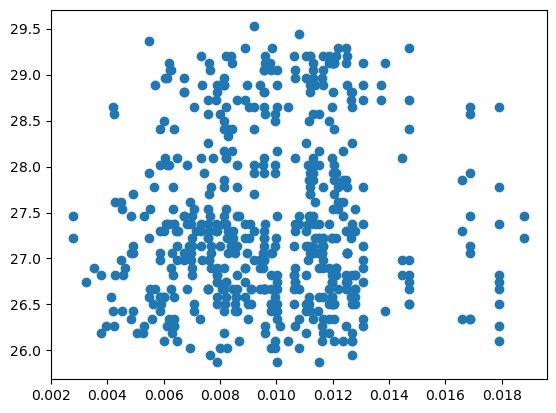

In [45]:
pl.figure()
pl.scatter(saved_all[990]['dm_mean_truth_all'], saved_all[990]['prop_all_truth'][:,0])
pl.show()



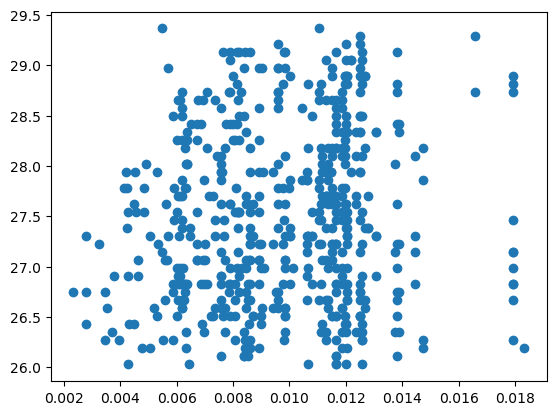

In [46]:
pl.figure()
pl.scatter(saved_all[990]['dm_mean_all'], saved_all[990]['prop_all'][:,0])
pl.show()



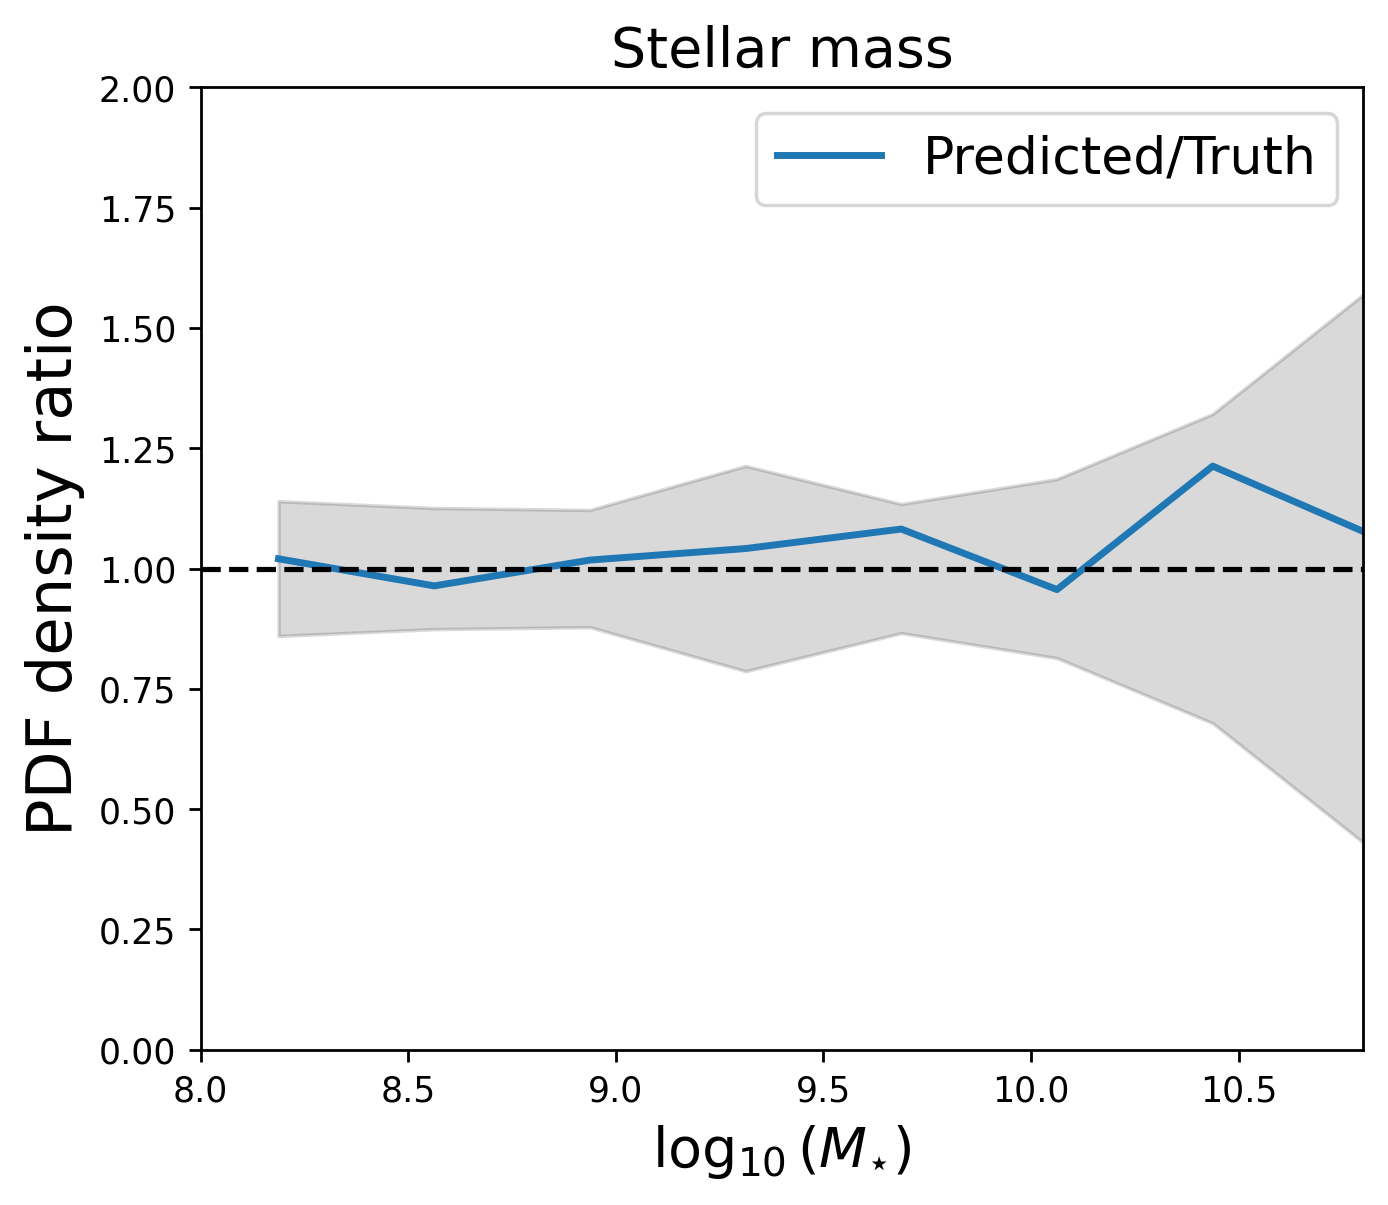

In [45]:
# snapnum = 90
# isim_fid = isim_fid_array[0]
# snap_dir_base = f'/work/hdd/bdne/spandey3/camels_tng/hydro/LH'
# snapdir = snap_dir_base + '/' + f'LH_{isim_fid}'  #folder hosting the catalogue
# group_catalog = f'{snapdir}/groups_090.hdf5'
# with h5.File(group_catalog, "r") as hf:
#     M_star = np.log10(hf['Subhalo/SubhaloMassType'][:,4]*1e10 + 0.1)
#     pos = hf['Subhalo/SubhaloPos'][:]/1000.

# Mstar_cut = 8
# indsel = np.where(M_star > Mstar_cut)[0]
# pos_h_truth = pos[indsel]
# prop_truth = M_star[indsel]
# prop_min = Mstar_cut
# prop_max = 11
hist_M_truth = []
hist_M_pred = []
hist_M_ratio = []
lgM_edges = np.linspace(8, 11, 9)
# lgM_edges = np.linspace(25, 30, 11)
lgM_cents = 0.5*(lgM_edges[1:] + lgM_edges[:-1])
for isim_fid in (isim_fid_array):
    # Mhalo_all_pred = saved_all[isim_fid]['prop_all'][:,-1]
    # Mhalo_all_truth = saved_all[isim_fid]['prop_all_truth'][:,-1]

    Mhalo_all_pred = saved_all[isim_fid]['prop_all'][:,3]
    Mhalo_all_truth = saved_all[isim_fid]['prop_all_truth'][:,3]    

    hist_pred = np.histogram(Mhalo_all_pred, bins=lgM_edges, density=True)[0]
    hist_truth = np.histogram(Mhalo_all_truth, bins=lgM_edges, density=True)[0]
    hist_ratio = hist_pred/hist_truth

    hist_M_truth.append(hist_truth)
    hist_M_pred.append(hist_pred)
    hist_M_ratio.append(hist_ratio)

hist_M_truth = np.array(hist_M_truth)
hist_M_pred = np.array(hist_M_pred)
hist_M_ratio = np.array(hist_M_ratio)

hist_M_truth_mean = np.mean(hist_M_truth, axis=0)
hist_M_truth_std = np.std(hist_M_truth, axis=0)
hist_M_pred_mean = np.mean(hist_M_pred, axis=0)
hist_M_ratio_mean = np.mean(hist_M_ratio, axis=0)
hist_M_truth_std = np.std(hist_M_ratio, axis=0)

pl.figure(figsize=(6, 5))
pl.plot(lgM_cents, hist_M_ratio_mean, label='Predicted/Truth', lw=2)
pl.fill_between(lgM_cents, 1 - hist_M_truth_std, 1 + hist_M_truth_std, alpha=0.15, color='k')
pl.axhline(1, color='k', ls='--')
pl.legend(fontsize=15)
# pl.xlim(26.8,29.4)
pl.xlim(8.0,10.8)
pl.ylim(0,2)
# pl.title('SDSS i-band photometry', fontsize=16)
pl.title('Stellar mass', fontsize=16)
# pl.xlabel(r'$\log_{10}(M_{i})$', fontsize=16)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=16)
pl.ylabel('PDF density ratio', fontsize=18)
pl.show()


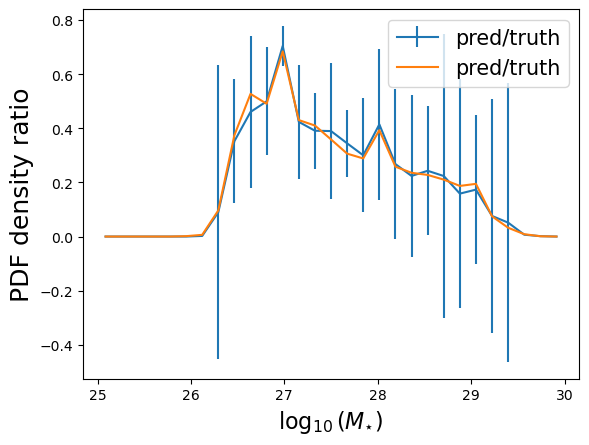

In [49]:
# np.array(Mhalo_all_concat).shape, np.array(Mhalo_all_truth_concat).shape
pl.figure()
pl.errorbar(lgM_cents, hist_M_truth_mean, hist_M_truth_std, label='pred/truth')
pl.errorbar(lgM_cents, hist_M_pred_mean, label='pred/truth')
# pl.fill_between(lgM_cents, 1 - hist_M_truth_std, 1 + hist_M_truth_std, alpha=0.3)
# pl.axhline(1, color='k', ls='--')
# pl.plot(lgM_cents, hist_M_pred_mean, label='pred')
# _ = pl.hist(np.array(Mhalo_all_concat), alpha=0.5, label='pred', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(Mhalo_all_truth_concat), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(prop_truth), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=16)
pl.ylabel('PDF density ratio', fontsize=18)
pl.show()



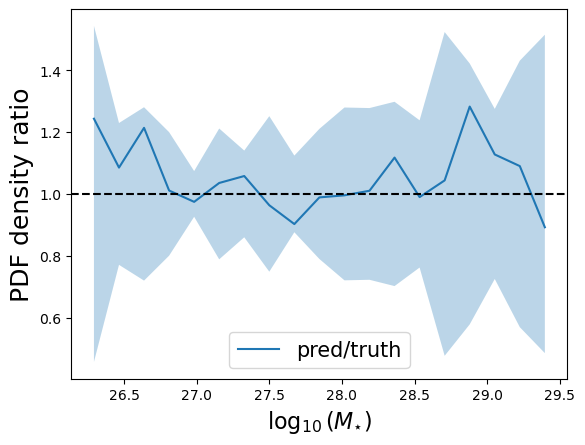

In [50]:
# np.array(Mhalo_all_concat).shape, np.array(Mhalo_all_truth_concat).shape
pl.figure()
pl.plot(lgM_cents, hist_M_ratio_mean, label='pred/truth')
pl.fill_between(lgM_cents, 1 - hist_M_truth_std, 1 + hist_M_truth_std, alpha=0.3)
pl.axhline(1, color='k', ls='--')
# pl.plot(lgM_cents, hist_M_pred_mean, label='pred')
# _ = pl.hist(np.array(Mhalo_all_concat), alpha=0.5, label='pred', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(Mhalo_all_truth_concat), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(prop_truth), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=16)
pl.ylabel('PDF density ratio', fontsize=18)
pl.show()



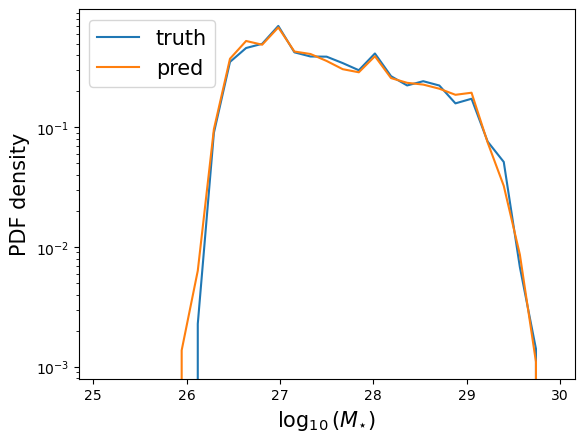

In [51]:
# np.array(Mhalo_all_concat).shape, np.array(Mhalo_all_truth_concat).shape
pl.figure()
pl.plot(lgM_cents, hist_M_truth_mean, label='truth')
pl.plot(lgM_cents, hist_M_pred_mean, label='pred')
# _ = pl.hist(np.array(Mhalo_all_concat), alpha=0.5, label='pred', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(Mhalo_all_truth_concat), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
# _ = pl.hist(np.array(prop_truth), alpha=0.5, label='truth', range=(8, 12), bins=15, density=True)
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\star})$', fontsize=15)
pl.ylabel('PDF density', fontsize=15)
pl.show()



In [52]:
# pos_all_concat.shape
import matplotlib
%matplotlib inline


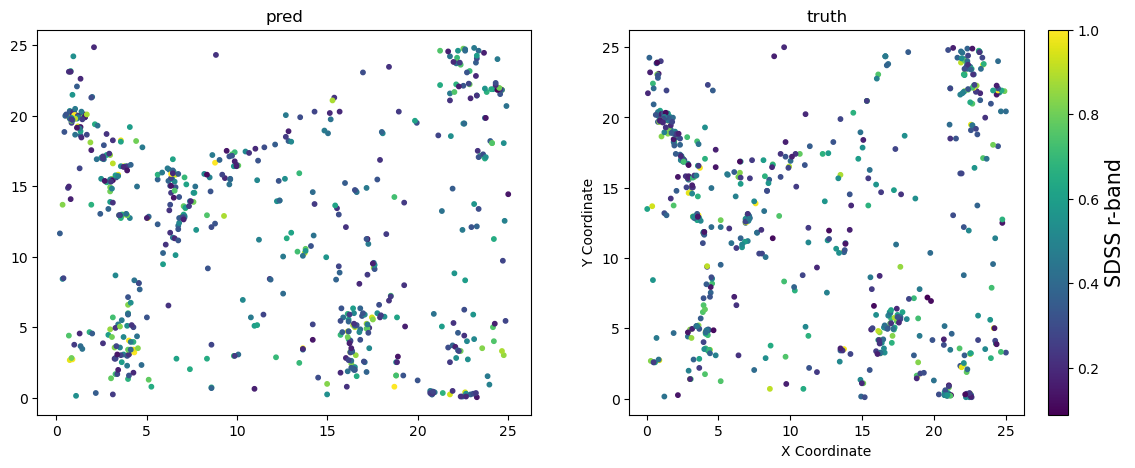

In [66]:
# pos_all_truth_concat.shape
isim_fid = 997
pl.figure(figsize=(14, 5))
# add subplot:
prop_min = 26
prop_max = 29

pl.subplot(1, 2, 1)
prop = np.clip((saved_all[isim_fid]['prop_all'][:,1] - prop_min)/(prop_max - prop_min), 0, 1)
pl.scatter(saved_all[isim_fid]['pos_all'][:,0], saved_all[isim_fid]['pos_all'][:,1], c=prop, cmap='viridis', s=10)
pl.title('pred')

pl.subplot(1, 2, 2)
prop = np.clip((saved_all[isim_fid]['prop_all_truth'][:,1] - prop_min)/(prop_max - prop_min), 0, 1)
sc = pl.scatter(saved_all[isim_fid]['pos_all_truth'][:,0], saved_all[isim_fid]['pos_all_truth'][:,1], c=prop, cmap='viridis', s=10)
pl.xlabel('X Coordinate')
pl.ylabel('Y Coordinate')
# pl.colorbar(sc, label='SDSS r-band', fontsize=15)
colorbar = pl.colorbar(sc)
colorbar.set_label('SDSS r-band', fontsize=15)
# plt.title('Scatter Plot Colored by Property')
pl.title('truth')
pl.show()


/tmp/ipykernel_284585/1669695737.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


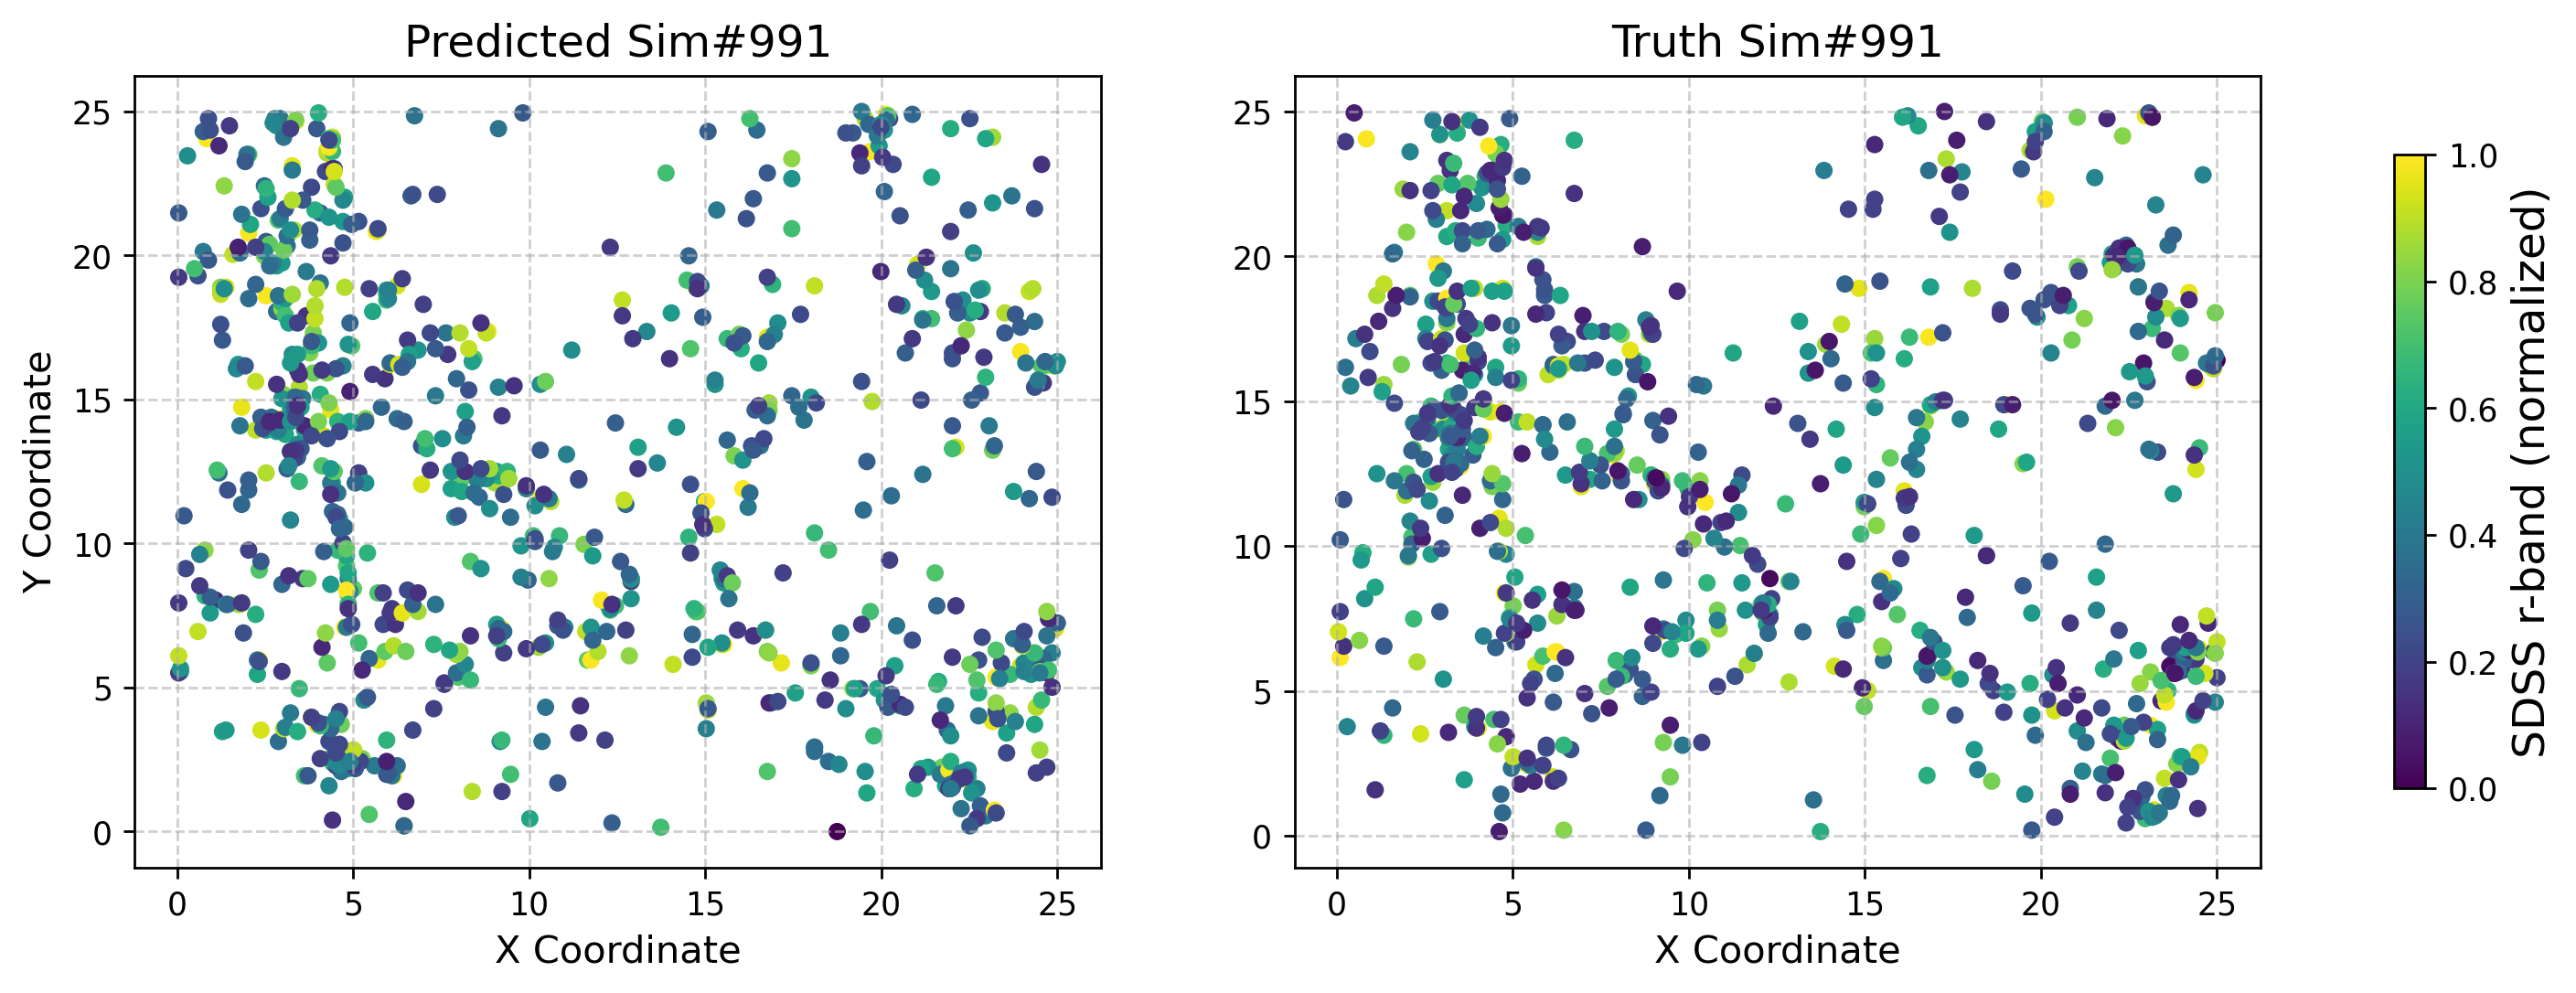

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
isim_fid = 991
prop_min = 26
prop_max = 29

# Example data for two panels
prop = np.clip((saved_all[isim_fid]['prop_all'][:,1] - prop_min)/(prop_max - prop_min), 0, 1)
x1, y1, property_values1 = saved_all[isim_fid]['pos_all'][:,0], saved_all[isim_fid]['pos_all'][:,1], prop

prop = np.clip((saved_all[isim_fid]['prop_all_truth'][:,1] - prop_min)/(prop_max - prop_min), 0, 1)
x2, y2, property_values2 = saved_all[isim_fid]['pos_all_truth'][:,0], saved_all[isim_fid]['pos_all_truth'][:,1], prop

# Combine property values for shared colorbar range
all_property_values = np.concatenate([property_values1, property_values2])

# Create a figure with two subplots
fig = plt.figure(figsize=(15, 4.5))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(x1, y1, c=property_values1, cmap='viridis', s=20)
ax1.set_title('Predicted Sim#991', fontsize=14)
ax1.set_xlabel('X Coordinate', fontsize=12)
ax1.set_ylabel('Y Coordinate', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(x2, y2, c=property_values2, cmap='viridis', s=20)
ax2.set_title('Truth Sim#991', fontsize=14)
ax2.set_xlabel('X Coordinate', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Shared colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_property_values), vmax=max(all_property_values))),
    ax=[ax1, ax2],
    orientation='vertical',
    shrink=0.8,
)
cbar.set_label('SDSS r-band (normalized)', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()



/tmp/ipykernel_284585/2529282994.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


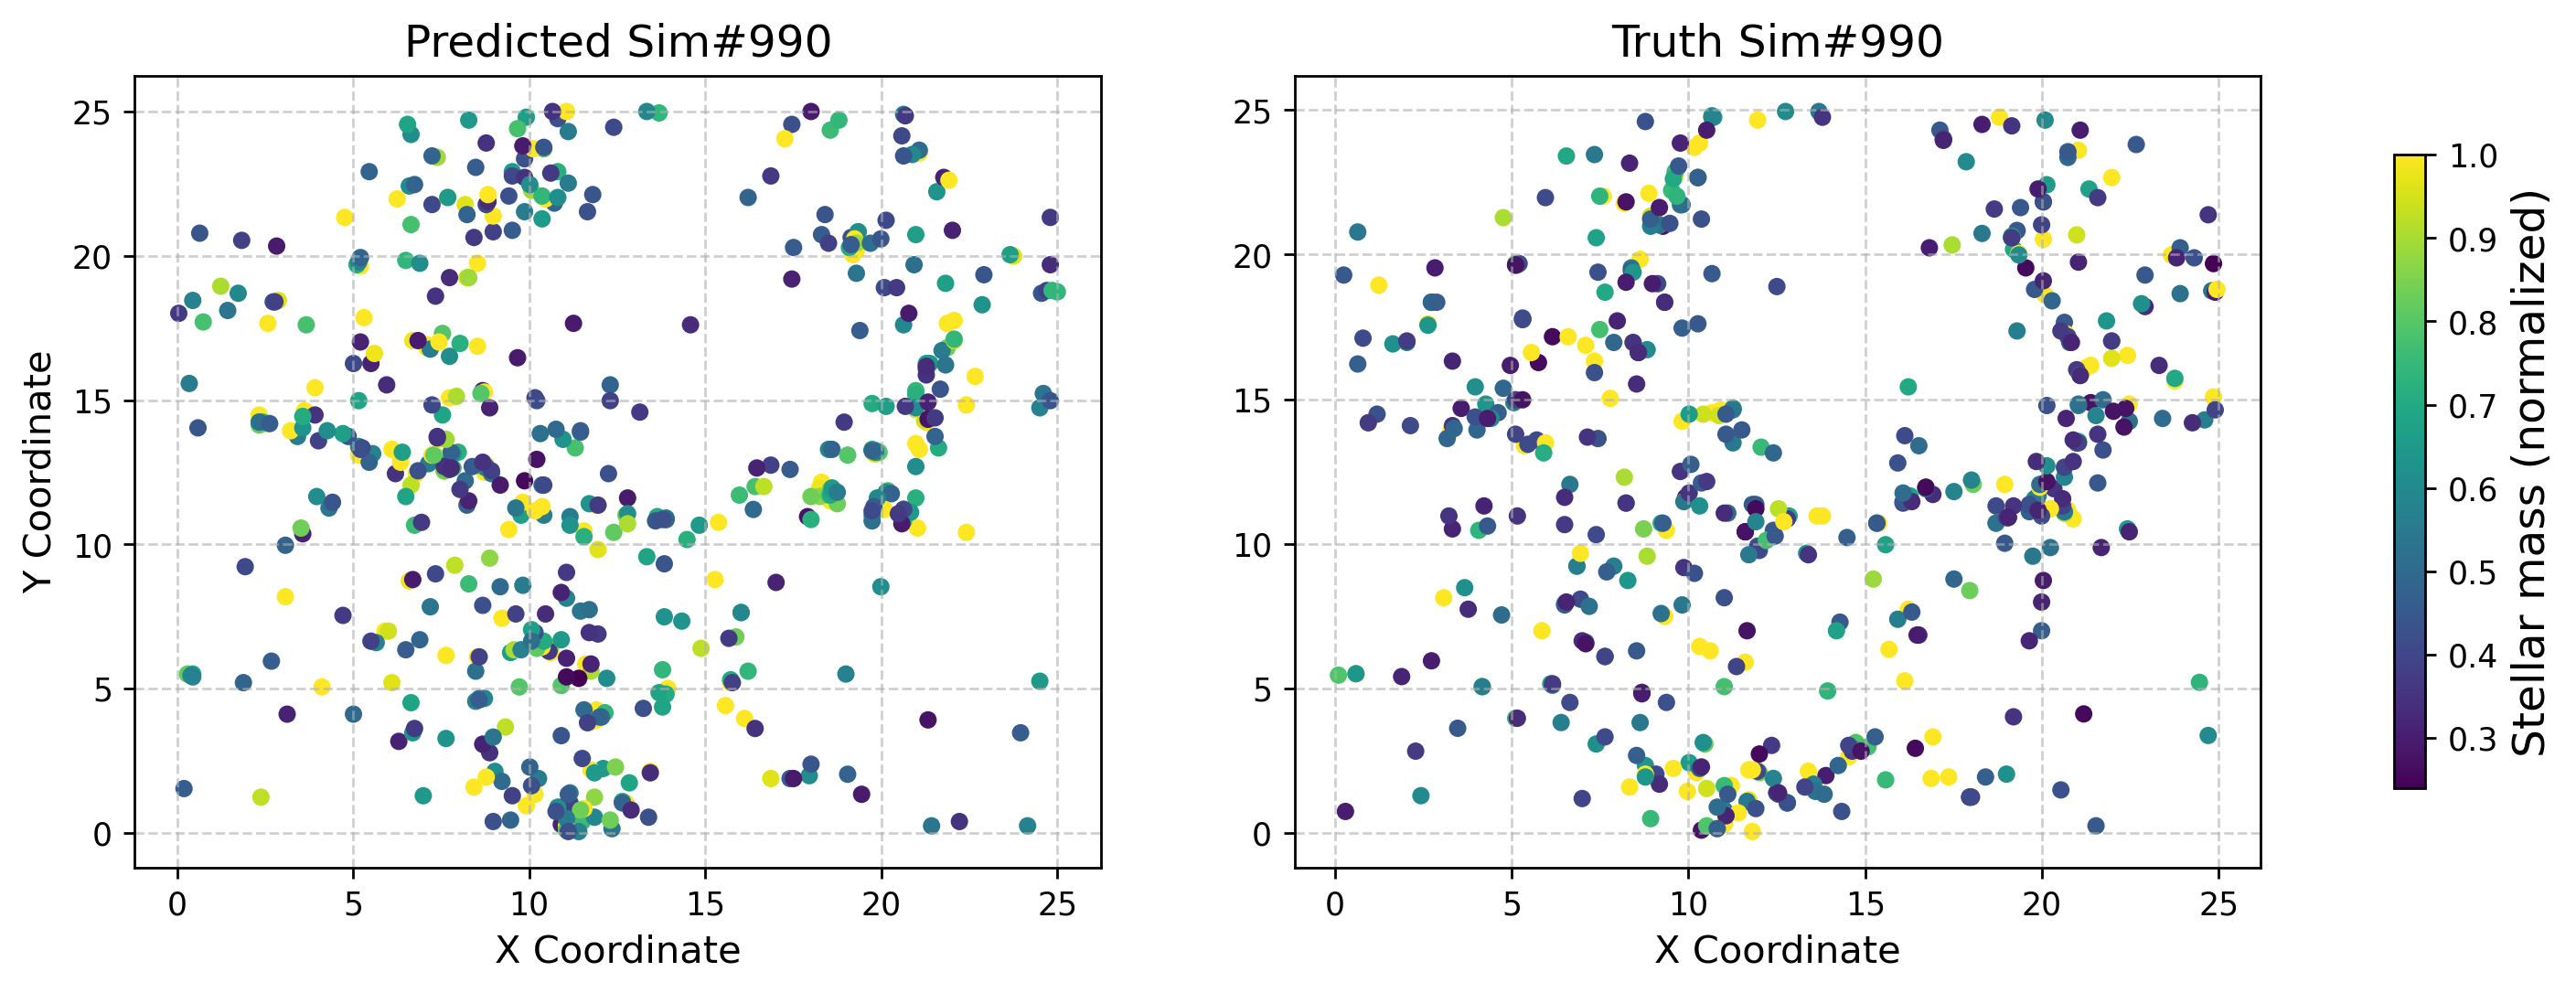

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
isim_fid = 990
prop_min = 7
prop_max = 10

# Example data for two panels
prop = np.clip((saved_all[isim_fid]['prop_all'][:,-1] - prop_min)/(prop_max - prop_min), 0, 1)
x1, y1, property_values1 = saved_all[isim_fid]['pos_all'][:,0], saved_all[isim_fid]['pos_all'][:,1], prop

prop = np.clip((saved_all[isim_fid]['prop_all_truth'][:,-1] - prop_min)/(prop_max - prop_min), 0, 1)
x2, y2, property_values2 = saved_all[isim_fid]['pos_all_truth'][:,0], saved_all[isim_fid]['pos_all_truth'][:,1], prop

# Combine property values for shared colorbar range
all_property_values = np.concatenate([property_values1, property_values2])

# Create a figure with two subplots
fig = plt.figure(figsize=(15, 4.5))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.2)

# First subplot
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(x1, y1, c=property_values1, cmap='viridis', s=20)
ax1.set_title('Predicted Sim#990', fontsize=14)
ax1.set_xlabel('X Coordinate', fontsize=12)
ax1.set_ylabel('Y Coordinate', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Second subplot
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(x2, y2, c=property_values2, cmap='viridis', s=20)
ax2.set_title('Truth Sim#990', fontsize=14)
ax2.set_xlabel('X Coordinate', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Shared colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(all_property_values), vmax=max(all_property_values))),
    ax=[ax1, ax2],
    orientation='vertical',
    shrink=0.8,
)
cbar.set_label('Stellar mass (normalized)', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()



In [20]:
saved_all[isim_fid]['prop_all_truth'].shape


(852, 4)

In [110]:
# isim_fid = 997
Pk_pred_all = []
Pk_truth_all = []
Pk_ratio_all = []

ind_prop = 2
normw = 10**27

# ind_prop = 3
# normw = 10**8

for isim_fid in isim_fid_array:
    grid_Pk = 32
    MAS = 'CIC'
    pos_truth = saved_all[isim_fid]['pos_all_truth']
    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    # MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS)
    W = (10**saved_all[isim_fid]['prop_all_truth'][:,ind_prop].astype(np.float32))/normw
    MASL.MA(pos_truth.astype(np.float32), mesh_truth, BoxSize, MAS , W=W) 
    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
    Pk_truth = PKL.Pk(mesh_truth, BoxSize, axis=0, MAS=None, threads=threads, verbose=False)
    Pk_truth_all.append(Pk_truth.Pk[:,0])

    pos_pred = saved_all[isim_fid]['pos_all']
    mesh_pred = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
    # MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS)
    W = 10**saved_all[isim_fid]['prop_all'][:,ind_prop].astype(np.float32)/normw
    MASL.MA(pos_pred.astype(np.float32), mesh_pred, BoxSize, MAS, W=W)     
    mesh_pred /= np.mean(mesh_pred, dtype=np.float64);  mesh_pred -= 1.0
    Pk_pred = PKL.Pk(mesh_pred, BoxSize, axis=0, MAS=None, threads=threads, verbose=False)
    Pk_pred_all.append(Pk_pred.Pk[:,0])

    Pk_ratio_all.append(Pk_pred.Pk[:,0]/Pk_truth.Pk[:,0])



In [111]:
Pk_pred_all = np.array(Pk_pred_all)
Pk_truth_all = np.array(Pk_truth_all)
Pk_ratio_all = np.array(Pk_ratio_all)


Pk_pred_mean = np.mean(Pk_pred_all, axis=0)
Pk_truth_mean = np.mean(Pk_truth_all, axis=0)
Pk_pred_std = np.std(Pk_pred_all, axis=0)
Pk_truth_std = np.std(Pk_truth_all, axis=0)

Pk_ratio_mean = np.mean(Pk_ratio_all, axis=0)
Pk_ratio_std = np.std(Pk_ratio_all, axis=0)


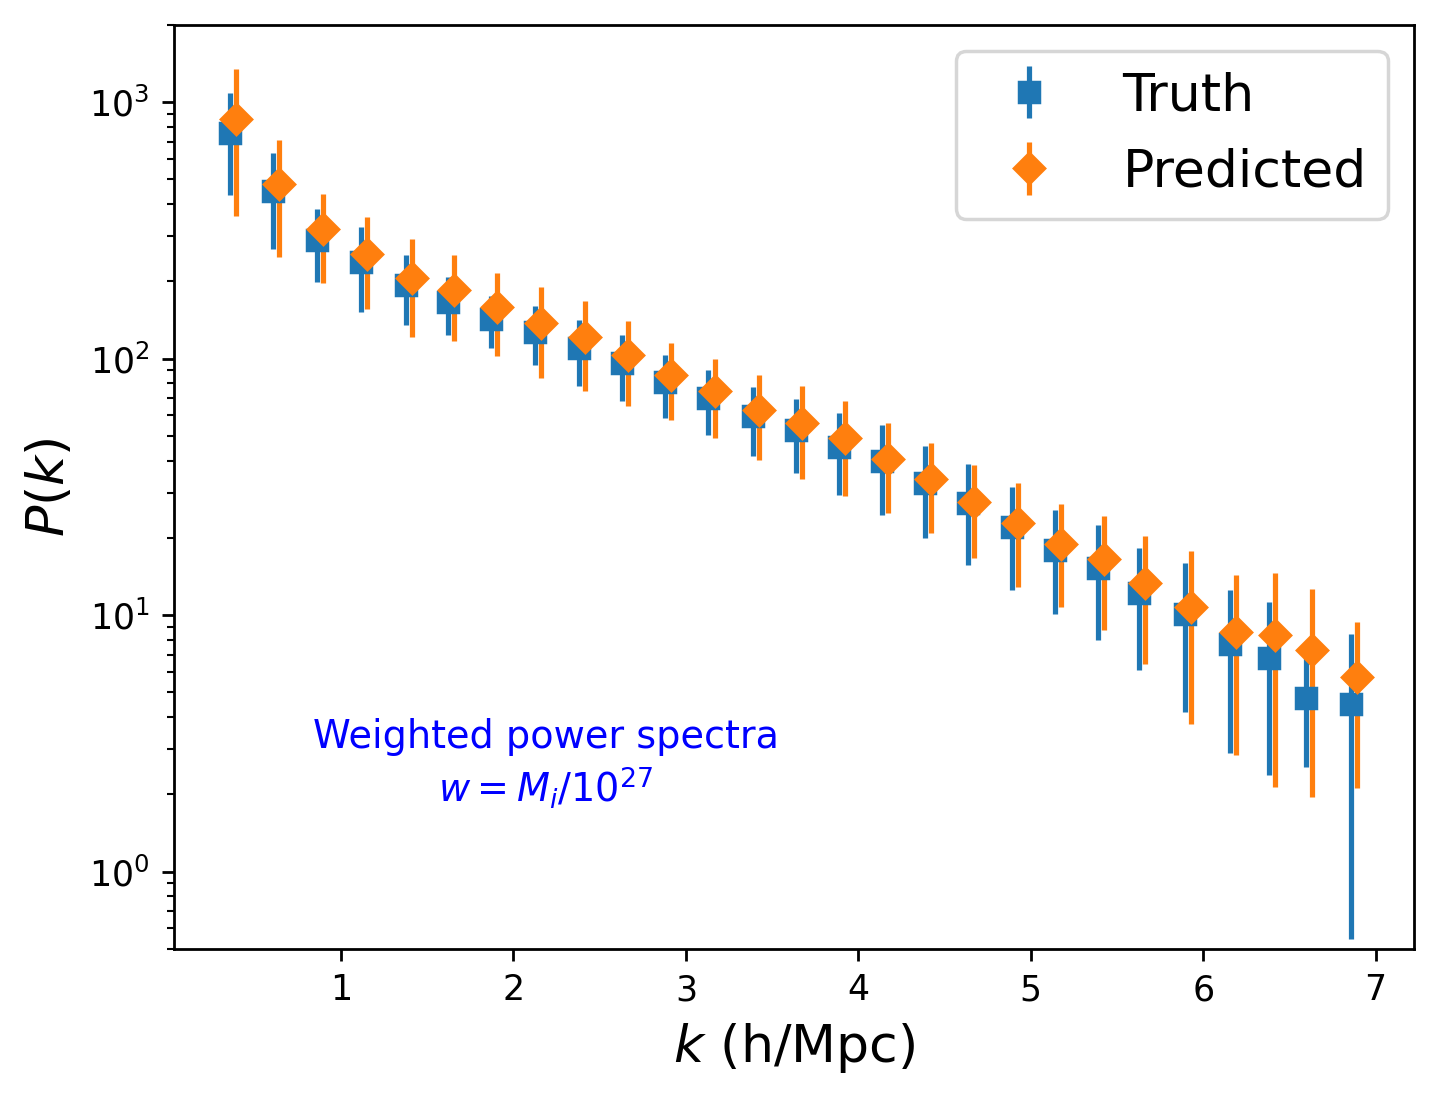

In [112]:
pl.figure()
pl.errorbar(Pk_truth.k3D, Pk_truth_mean, yerr=Pk_truth_std, label='Truth', ls='', marker='s')
pl.errorbar(Pk_pred.k3D+0.035, Pk_pred_mean, yerr=Pk_pred_std, label='Predicted', ls='', marker='D')
pl.yscale('log')
pl.xlabel(r'$k$ (h/Mpc)', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)
pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_i/10^{27}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Weighted power spectra' + '\n' + r'$w = M_{\star}/10^{8}$', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
# pl.text(0.3, 0.2, 'Un-weighted power spectra', transform=pl.gca().transAxes, fontsize=11, color='blue', ha='center', va='center')
pl.ylim(0.5,2e3)
pl.legend(fontsize=15)



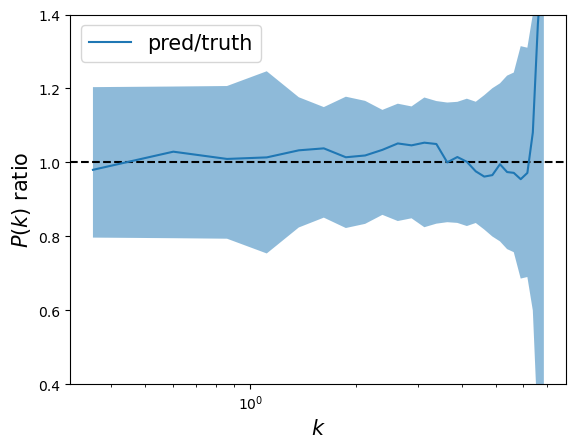

In [38]:
pl.figure()
pl.errorbar(Pk_truth.k3D, Pk_ratio_mean, label='pred/truth')
pl.fill_between(Pk_truth.k3D, 1 - Pk_ratio_std, 1+ Pk_ratio_std, alpha=0.5)
# pl.errorbar(Pk_pred.k3D*1.02, Pk_pred_mean, yerr=Pk_pred_std, label='pred')
pl.xscale('log')
# pl.yscale('log')
pl.axhline(1.0, ls='--', color='k')
pl.ylim(0.4, 1.4)
pl.xlabel(r'$k$', fontsize=15)
pl.ylabel(r'$P(k)$ ratio', fontsize=15)
pl.legend(fontsize=15)



Text(0, 0.5, '$P(k)$')

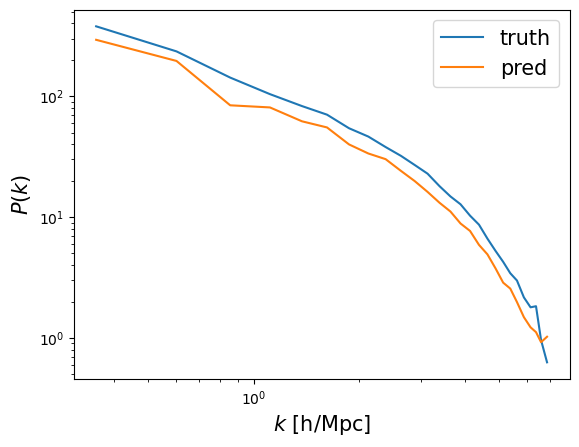

In [75]:
pl.figure()
pl.plot(Pk_truth.k3D, Pk_truth.Pk[:,0], label='truth')
pl.plot(Pk_pred.k3D, Pk_pred.Pk[:,0], label='pred')
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$k$ [h/Mpc]', fontsize=15)
pl.ylabel(r'$P(k)$', fontsize=15)




In [76]:
# isim_fid_array = np.arange(7, 11)
# isim_fid_array = np.arange(0, 3)
# isim_fid = 6
# for isim_fid in isim_fid_array:
isim_fid = 3
df = pk.load(open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_{isim_fid}_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))

dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_0 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_0 = df['Nhalos_truth']
delta_box_all_squeezed_0 = df['delta_box_all_squeezed']


grid = 32
shift_x_all, shift_y_all, shift_z_all = np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid)), np.zeros((grid, grid, grid))
for jx in range(grid):
    for jy in range(grid):
        for jz in range(grid):
            shift_x_all[jx, jy, jz] = jx
            shift_y_all[jx, jy, jz] = jy
            shift_z_all[jx, jy, jz] = jz

shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed = shift_x_all.flatten(), shift_y_all.flatten(), shift_z_all.flatten()
shift_all_squeezed = np.vstack([shift_x_all_squeezed, shift_y_all_squeezed, shift_z_all_squeezed]).T


n1 = 32**3
test_data_halos = dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0[:n1]

test_data_dm = delta_box_all_squeezed_0[:n1]

x = torch.tensor(test_data_halos[:, :-1])
y = torch.tensor(test_data_halos[:, 1:])
dm = torch.tensor(test_data_dm)
mask_test_orig = x != 1
mask_test = torch.logical_not(mask_test_orig)
masked_logits = torch.zeros(mask_test.shape)
mask_test_final = masked_logits.masked_fill(mask_test, float('-inf'))
mask_test = mask_test_final[:,None,:]
x, y = torch.tensor(x), torch.tensor(y)
x_test = x.long()
y_test = y.long()
dm_test = dm.bfloat16()
mask_test = torch.tensor(mask_test).bfloat16()

x_test_gpu = x_test.to(dev)
y_test_gpu = y_test.to(dev)
dm_test_gpu = dm_test.to(dev)
mask_test_gpu = mask_test.to(dev)


def get_batch(split, ji=0, batch_size=None):
    if split == 'train':
        x = x_train_gpu
        y = y_train_gpu
        mask = mask_train_gpu
        dm = dm_train_gpu

    elif split == 'val':
        x = x_val_gpu
        y = y_val_gpu
        mask = mask_val_gpu
        dm = dm_val_gpu

    elif split == 'test':
        x = x_test_gpu
        y = y_test_gpu
        mask = mask_test_gpu
        dm = dm_test_gpu        

    if batch_size is not None:
        x = x[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
        y = y[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
        mask = mask[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)
        dm = dm[batch_size*(ji):batch_size*(ji+1)].to(dev, non_blocking=True)

    return x, y, mask, dm

batch_size = 32**3
X_val, Y_val, MASK_val, DM_val = get_batch('test', 0, batch_size)
DM_val = torch.moveaxis(DM_val, -1, 1)
# DM_val.shape

DM_val_tosplit = DM_val.detach().cpu().to(torch.float16).numpy()[:batch_size, 0,:,:,:].reshape(batch_size, DM_val.shape[-1]**3)
DM_val_tosplit_mean = np.mean(DM_val_tosplit, axis=-1)

vlow = 0.00075
vmid = 0.0017

indlow = np.where(DM_val_tosplit_mean < vlow)[0]
indmid = np.where((DM_val_tosplit_mean >= vlow) & (DM_val_tosplit_mean < vmid))[0]
indhigh = np.where(DM_val_tosplit_mean >= vmid)[0]

print(len(indlow), len(indmid), len(indhigh))

max_new_tokens = df['max_sentence_length']
nvocab = df['nvocab_total'] - 3

bins_digitize = np.linspace(-1e-3, 1, nvocab)
# bins_digitize.insert(0, -1)
bins_digitize = np.insert(bins_digitize, 0, -1)


start_token = 0
pad_token = 1
end_token = nvocab + 1
space_token = nvocab + 2


from tqdm import tqdm

# end_token = 65
# nvox_samp = 32**3
# nbatches = 32
fac = 32
nvox_samp = fac*32**2
nbatches = fac
nvox_per_batch = nvox_samp // nbatches

# idx_all = []
# idx_all = torch.ones((nvox_samp, max_new_tokens), dtype=torch.long, device=dev)
idx_all = np.ones((nvox_samp, max_new_tokens))
for jb in tqdm(range(nbatches)):

    idx_inp = torch.zeros((nvox_per_batch, 1), dtype=torch.long, device=dev)

    DM_val_jb = DM_val[jb*nvox_per_batch:(jb+1)*nvox_per_batch,...]

    new_samples_jb = np.ones((nvox_per_batch, max_new_tokens))

    ind_jb = np.arange(nvox_per_batch)

    new_samples_jb[:, 0] = idx_inp[:,0].cpu().detach().numpy()
    # idx = idx_inp
    for jt in range(1, max_new_tokens):
        if len(ind_jb) > 0:
            # crop idx to the last block_size tokens
            idx_cond = torch.tensor(new_samples_jb[ind_jb, :jt], dtype=torch.long, device=dev)
            # get the predictions
            logits, loss = model(idx_cond, DM_val_jb[ind_jb,...])
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1).cpu().detach().numpy() # (B, 1)

            # append sampled index to the running sequence
            # if idx_next == end_token:
                # break
            new_samples_jb[ind_jb, jt] = idx_next[:,0]
            ind_to_del = np.where(idx_next[:,0] == end_token)[0]
            # for jv in range(len(ind_jb)):
                # if idx_next[jv, 0] == end_token:
            if len(ind_to_del) > 0:
                ind_jb = np.delete(ind_jb, ind_to_del)


        # print(new_samples_jb[0,:])
        # idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
    idx_all[jb*nvox_per_batch:(jb+1)*nvox_per_batch, :] = new_samples_jb
    # idx_all.append(idx)



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_3_snap_3_nvocab64_Mmin_1e13p5.pkl'

In [14]:
# jv = 465
jv = indhigh[0]
id_start = 0
id_space = idx_all[jv][::5][1:]
M_jv = idx_all[jv, 1:][::5]
id_space, M_jv


(array([66., 66., 66., 66., 66., 66., 66., 66., 66., 66., 65.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.]),
 array([33., 31., 27., 15., 11., 11.,  9.,  9.,  8.,  5.,  3.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.]))

In [15]:
# idx_all[jv]
np.diff(M_jv)


array([ -2.,  -4., -12.,  -4.,   0.,  -2.,   0.,  -1.,  -3.,  -2.,  -2.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.])

In [22]:
from tqdm import tqdm
id_space_wrong = []
id_non_desc = []
num_space_wrong = []
for jv in tqdm(range(nvox_samp)):
    idx_jv = idx_all[jv,:]
    id_space_jv = idx_all[jv][::5][1:]
    M_jv = idx_all[jv, 1:][::5]

    if np.any(np.isin(id_space_jv, np.array([space_token, end_token, pad_token])) != True):
        id_space_wrong.append(jv)
        num_space_wrong.append(np.sum(np.isin(id_space_jv, np.array([space_token, end_token, pad_token])) != True))
    
    if np.any(np.diff(M_jv) > 0):
        id_non_desc.append(jv)



100%|██████████| 32768/32768 [00:00<00:00, 43925.88it/s]


In [2]:
# id_space_jv
# id_space_jv  [space_token, end_token, pad_token]
# np.isin(id_space_jv, np.array([space_token, end_token, pad_token]))
# id_space_wrong, id_non_desc
# id_non_desc[0]
# idx_all[id_non_desc[10]]
# len(id_non_desc)
# len(id_space_wrong)
# idx_all[id_space_wrong[20]]
import h5py as h5
f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'r')
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = f['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all'][:]
delta_box_all_squeezed_all = f['delta_box_all_squeezed_all'][:]
nvocab_total = f['nvocab_total'][()]
grid_size = f['grid'][()]
start_token = f['start_token'][()]
pad_token = f['pad_token'][()]
end_token = f['end_token'][()]
max_sentence_length = f['max_sentence_length'][()]
f.close()


In [3]:
max_sentence_length



101

In [29]:
isim_fid_array = np.arange(0, 10)
M_all = []
snapnum = 3
mass_type = 'rockstar_200c'
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'

for isim_fid in isim_fid_array:
    snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
    rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
    with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
        lines = f.readlines()
    header = lines[0].split()

    index_M = header.index('M200c')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
    M_all.append(mass_truth)




In [30]:
logM_all = np.log10(np.concatenate(M_all))



/tmp/ipykernel_1104866/26522825.py:1: RuntimeWarning: divide by zero encountered in log10
  logM_all = np.log10(np.concatenate(M_all))


In [35]:
from colossus.cosmology import cosmology
params = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}
cosmo = cosmology.setCosmology('myCosmo', **params)
# get halo mass function:
from colossus.lss import mass_function
lgMmin = 12.5
lgMmax = 15.5
lgM_array = np.linspace(lgMmin, lgMmax, 1000)
M_array = 10**lgM_array
z_inference = 0.5
# if '200c' in mass_type:
dndlnM = mass_function.massFunction(M_array, float(z_inference), mdef = '200c', model = 'tinker08', q_out = 'dndlnM')

dlnM = np.log(M_array[1]/M_array[0])
dndM = dndlnM * M_array
dn = dndM * dlnM
n = np.cumsum(dn)



In [33]:
len(n), len(M_array)


(1000, 1000)

Text(0, 0.5, 'Histogram')

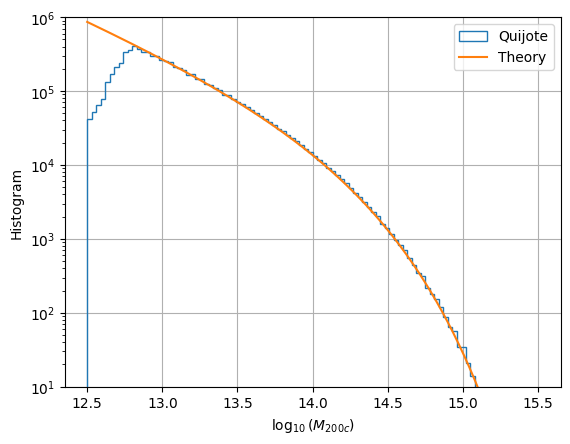

In [55]:
pl.figure()
_ = pl.hist(logM_all,bins=100, histtype='step', range=(12.5, 15.5), label='Quijote')
pl.plot(lgM_array, 0.6711*dndlnM * 1e9, label='Theory')
# pl.plot(lgM_array, n, label='Theory')
pl.yscale('log')
pl.ylim(10, 1e6)
pl.grid()
pl.legend()
pl.xlabel(r'$\log_{10}(M_{200c})$')
pl.ylabel(r'Histogram')


In [134]:
Mmin_cut = 10**13.5
lgMin = np.log10(Mmin_cut)
lgMax = 15.5

BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2

Nhalo_all_truth = []
Mhalo_all_truth = []
pos_all_truth = []
Pk_all_truth = []

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 16
threads = 10

for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten().astype(int)
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all_truth.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))        
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                # if jx == 0:
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord        
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord    
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                    Mhalo_all_truth.append(Mhalo)
                    pos_all_truth.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all_truth.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all_truth.append([])

                except:
                    Nhalo_all_truth.pop()
                    Nhalo_all_truth.append(0)
                    Mhalo_all_truth.append(np.array([]))
                    pos_all_truth.append(np.array([]))
                    Pk_all_truth.append([])
                    pass
        else:
            Nhalo_all_truth.append(0)            
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])
    else:
        Nhalo_all_truth.append(0)  
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])

Nhalo_all = []
Mhalo_all = []
pos_all = []
Pk_all = []


for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = idx_all[jv].astype(int)
    idx = idx.flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:

    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord    
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord   
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord 
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord


                    Mhalo_all.append(Mhalo)
                    pos_all.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all.append([])


                except Exception as e:
                    Nhalo_all.pop()
                    Nhalo_all.append(0)
                    Mhalo_all.append(np.array([]))
                    pos_all.append(np.array([]))
                    Pk_all.append([])
                    # print(jv, e)
                    pass

        else:
            # Nhalo_all.append(np.array([]))
            Nhalo_all.append(0)            
            Mhalo_all.append(np.array([]))
            pos_all.append(np.array([]))
            Pk_all.append([])

    else:
        # Nhalo_all.append(np.array([]))
        Nhalo_all.append(0)                    
        Mhalo_all.append(np.array([]))
        pos_all.append(np.array([]))
        Pk_all.append([])


Nhalo_all_truth_concat = []
for jv in range(len(Nhalo_all_truth)):
    if type(Nhalo_all_truth[jv]) == int:
        Nhalo_all_truth_concat.append(Nhalo_all_truth[jv])

Nhalo_all_concat = []
for jv in range(len(Nhalo_all)):
    if type(Nhalo_all[jv]) == int:
        Nhalo_all_concat.append(Nhalo_all[jv])  

    
Mhalo_all_truth_concat = []
for jv in range(len(Mhalo_all_truth)):
    Mhalo_all_truth_concat.extend(Mhalo_all_truth[jv])

Mhalo_all_concat = []
for jv in range(len(Mhalo_all)):
    Mhalo_all_concat.extend(Mhalo_all[jv])  

    
pos_all_truth_concat = []
for jv in range(len(pos_all_truth)):
    if len(pos_all_truth[jv]) > 0:
        if len(pos_all_truth_concat) == 0:
            pos_all_truth_concat = pos_all_truth[jv]
        else:
            pos_all_truth_concat = np.vstack((pos_all_truth_concat, pos_all_truth[jv]))
        # pos_all_truth_concat.extend(pos_all_truth[jv])

pos_all_concat = []
for jv in range(len(pos_all)):
    if len(pos_all[jv]) > 0:
        if len(pos_all_concat) == 0:
            pos_all_concat = pos_all[jv]
        else:
            pos_all_concat = np.vstack((pos_all_concat, pos_all[jv]))
        # pos_all_concat.extend(pos_all[jv])  


saved = {'pos_all':pos_all_concat,
            'pos_all_truth':pos_all_truth_concat,
            'Mhalo_all':Mhalo_all_concat,
            'Mhalo_all_truth':Mhalo_all_truth_concat,
            'Nhalo_all':Nhalo_all_concat,
            'Nhalo_all_truth':Nhalo_all_truth_concat,
            # 'Pk_all':Pk_all_concat,
            # 'Pk_all_truth':Pk_all_truth_concat
            }

# pk.dump(saved, open(f'/mnt/home/spandey/ceph/CHARFORMER/results/pos_M_Nhalo_all_truth_concat_PM_isim_{isim_fid}_nvocab_64_nembed_64_Mmin_1e13p5.pkl', 'wb'))

        


/tmp/ipykernel_708657/2682590823.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/2682590823.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord
/tmp/ipykernel_708657/2682590823.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp/i

/tmp/ipykernel_708657/2682590823.py:120: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/2682590823.py:123: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord
/tmp/ipykernel_708657/2682590823.py:135: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp

In [ ]:
Nhalo_all_truth = []
Mhalo_all_truth = []
pos_all_truth = []
Pk_all_truth = []

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 16
threads = 10

for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten().astype(int)
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all_truth.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))        
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                # if jx == 0:
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord        
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord    
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                    Mhalo_all_truth.append(Mhalo)
                    pos_all_truth.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all_truth.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all_truth.append([])

                except:
                    Nhalo_all_truth.pop()
                    Nhalo_all_truth.append(0)
                    Mhalo_all_truth.append(np.array([]))
                    pos_all_truth.append(np.array([]))
                    Pk_all_truth.append([])
                    pass
        else:
            Nhalo_all_truth.append(0)            
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])
    else:
        Nhalo_all_truth.append(0)  
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])


/tmp/ipykernel_708657/841951432.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/841951432.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin  + shift_coord
/tmp/ipykernel_708657/841951432.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp/ipyk

In [ ]:
# idx0, idxe
# jtest= 1288
jtest = np.where(np.array(Nhalo_all_truth) == 0)[0][0]
len(pos_all_truth[jtest]), Nhalo_all_truth[jtest], len(Mhalo_all_truth[jtest])



(0, 0, 0)

In [ ]:
Nhalo_all = []
Mhalo_all = []
pos_all = []
Pk_all = []


for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = idx_all[jv].astype(int)
    idx = idx.flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:

    if len(idx0) == 1:
        if idx[idx0] != end_token:
            Nhalo = len(idxe) + len(idx0)
            Nhalo_all.append(Nhalo)
            pos_halo = np.zeros((Nhalo, 3))
            pos_halo_unshifted = np.zeros((Nhalo, 3))
            if Nhalo > 0:
                try:
                    Mhalo = np.zeros(Nhalo)
                    for jh in range(Nhalo):
                        if jh == 0:
                            Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord    
                                pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                        else:
                            if Nhalo > 2:
                                Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin  + shift_coord   
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord

                            else:
                                Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                                for jx in range(3):
                                    shift_coord = shift_all_squeezed[jv, jx] * (2 * xmin)
                                    pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin  + shift_coord 
                                    pos_halo_unshifted[jh, jx] = pos_halo[jh, jx] - shift_coord


                    Mhalo_all.append(Mhalo)
                    pos_all.append(pos_halo)

                    if Nhalo > 5:
                        mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                        MASL.MA(pos_halo_unshifted.astype(np.float32), mesh_truth, 2*xmin, MAS)
                        mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                        Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                        Pk_all.append(Pk_truth.Pk[:,0])
                    else:
                        Pk_all.append([])


                except Exception as e:
                    Nhalo_all.pop()
                    Nhalo_all.append(0)
                    Mhalo_all.append(np.array([]))
                    pos_all.append(np.array([]))
                    Pk_all.append([])
                    # print(jv, e)
                    pass

        else:
            # Nhalo_all.append(np.array([]))
            Nhalo_all.append(0)            
            Mhalo_all.append(np.array([]))
            pos_all.append(np.array([]))
            Pk_all.append([])

    else:
        # Nhalo_all.append(np.array([]))
        Nhalo_all.append(0)                    
        Mhalo_all.append(np.array([]))
        pos_all.append(np.array([]))
        Pk_all.append([])



/tmp/ipykernel_708657/657509725.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_708657/657509725.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin + shift_coord
/tmp/ipykernel_708657/657509725.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
/tmp/ipyke

In [ ]:
# np.array(Nhalo_all_truth).shape, 32**3
# np.array(Nhalo_all).shape, 32**3
# idx0, idxe
jtest= 1243
# jtest = np.where(np.array(Nhalo_all_truth) == 0)[0][0]
print(len(pos_all[jtest]), Nhalo_all[jtest], len(Mhalo_all[jtest]))
# print(len(pos_all_truth[jtest]), Nhalo_all_truth[jtest], len(Mhalo_all_truth[jtest]))




2 2 2


In [ ]:
# np.amin(np.array(Nhalo_all))


Text(0, 0.5, '$P_{\\rm mock}(k)/P_{\\rm truth}(k)$')

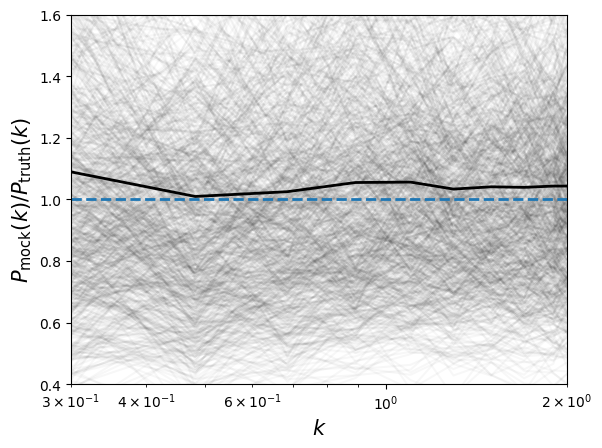

In [ ]:
pl.figure()
resid_all = []
# for jp in range(len(Pk_all)):
# for jp in indhigh:    
Pk_all_concat = []
Pk_all_truth_concat = []
# for jp in indlow:        
for jp in indhigh:       
# for jp in indmid:           
# for jp in range(nvox_samp):
# for jp in indmid[::10]:            
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        # pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.0003)
        pl.plot(Pk_truth.k3D, (Pk_all[jp])/(Pk_all_truth[jp]), color='k', ls='-', alpha=0.03)
        resid_all.append((Pk_all[jp])/Pk_all_truth[jp])
        Pk_all_concat.append(Pk_all[jp])
        Pk_all_truth_concat.append(Pk_all_truth[jp])

Pk_all_concat = np.vstack(Pk_all_concat)
Pk_all_truth_concat = np.vstack(Pk_all_truth_concat)

resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(0.4, 1.6)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)




Text(0, 0.5, '$P_{\\rm mock}(k)/P_{\\rm truth}(k)$')

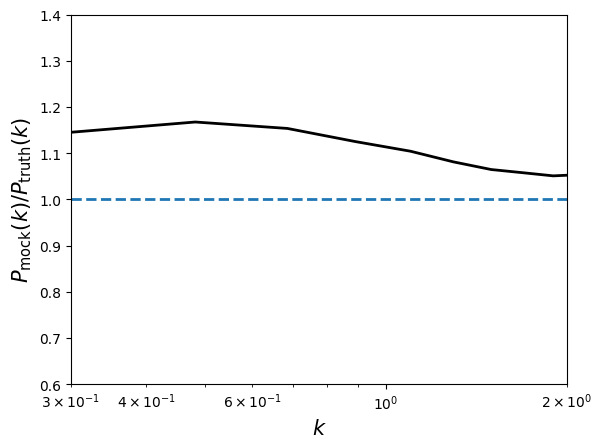

In [171]:
pl.figure()
resid_all = []
# for jp in range(len(Pk_all)):
# for jp in indhigh:    
Pk_all_concat = []
Pk_all_truth_concat = []
# for jp in indlow:        
# for jp in indhigh:       
for jp in range(nvox_samp):
# for jp in indmid[::10]:            
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        # pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.0003)
        pl.plot(Pk_truth.k3D, (Pk_all[jp])/(Pk_all_truth[jp]), color='k', ls='-', alpha=0.0003)
        resid_all.append((Pk_all[jp])/Pk_all_truth[jp])
        Pk_all_concat.append(Pk_all[jp])
        Pk_all_truth_concat.append(Pk_all_truth[jp])

Pk_all_concat = np.vstack(Pk_all_concat)
Pk_all_truth_concat = np.vstack(Pk_all_truth_concat)

resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)




Text(0.5, 1.0, 'Power spectra of 32Mpc/$h$ sub-boxes')

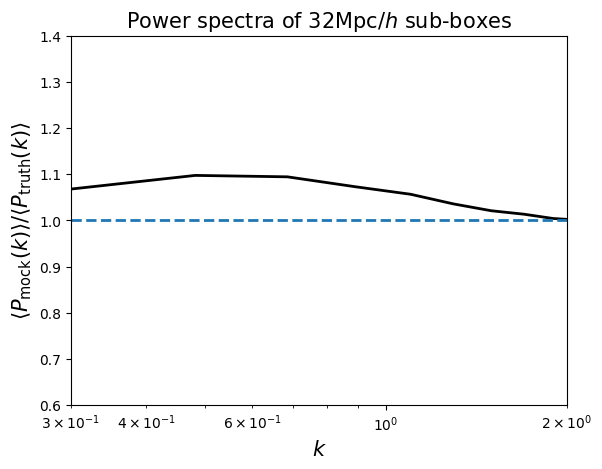

In [172]:
pl.figure()
pl.plot(Pk_truth.k3D, np.mean(Pk_all_concat, axis=0)/np.mean(Pk_all_truth_concat, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\langle P_{\rm mock}(k) \rangle/\langle P_{\rm truth}(k) \rangle$', size=15)
pl.title(r'Power spectra of 32Mpc/$h$ sub-boxes', size=15)




Text(0.5, 1.0, 'Power spectra of 32Mpc/$h$ sub-boxes')

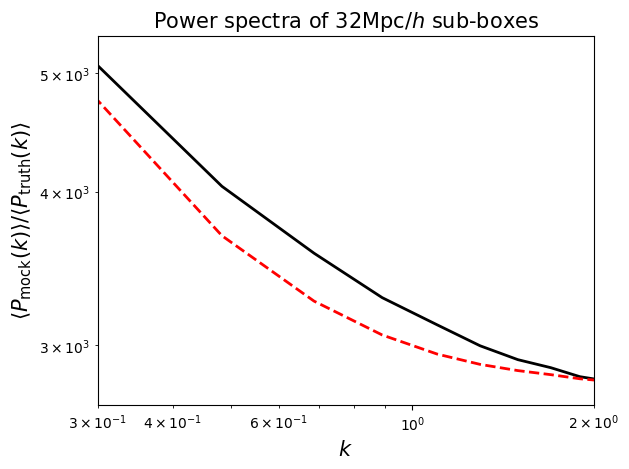

In [173]:
pl.figure()
pl.plot(Pk_truth.k3D, np.mean(Pk_all_concat, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.plot(Pk_truth.k3D, np.mean(Pk_all_truth_concat, axis=0), color='r', ls='--', alpha=1.0, lw=2.0)
# pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\langle P_{\rm mock}(k) \rangle/\langle P_{\rm truth}(k) \rangle$', size=15)
pl.title(r'Power spectra of 32Mpc/$h$ sub-boxes', size=15)




In [174]:
# Pk_all_concat.shape
# Pk_truth.k3D


Text(0.5, 1.0, 'Power spectra of 32Mpc/$h$ sub-boxes')

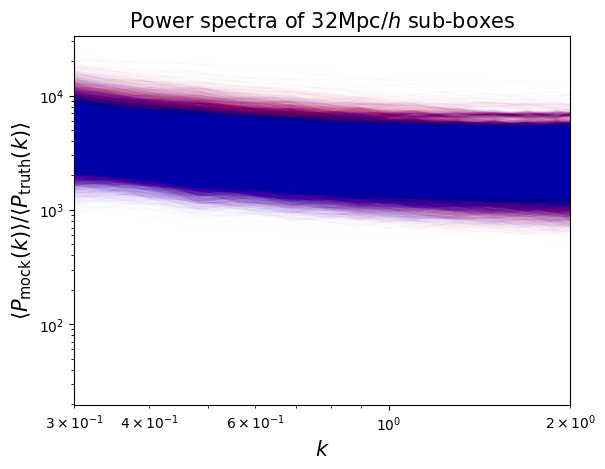

In [175]:
pl.figure()
for jp in range(len(Pk_all_concat)):
    pl.plot(Pk_truth.k3D, (Pk_all_concat[jp]), color='r', ls='-', alpha=0.01, lw=1.0)
for jp in range(len(Pk_all_concat)):    
    pl.plot(Pk_truth.k3D, (Pk_all_truth_concat[jp]), color='b', ls='-', alpha=0.01, lw=1.0)
# pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.6, 1.4)
pl.xlim(0.3, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\langle P_{\rm mock}(k) \rangle/\langle P_{\rm truth}(k) \rangle$', size=15)
pl.title(r'Power spectra of 32Mpc/$h$ sub-boxes', size=15)




In [176]:
# pl.figure()
# resid_all = []
# # for jp in range(len(Pk_all)):
# # for jp in indhigh:    
# for jp in indlow:        
#     if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
#         # pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.0003)
#         pl.plot(Pk_truth.k3D, (Pk_all[jp])/(Pk_all_truth[jp]), color='k', ls='-', alpha=0.03)
#         resid_all.append((Pk_all[jp])/Pk_all_truth[jp])

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
# pl.axhline(1.0, ls='--', lw=2.0)
# pl.xscale('log')
# pl.ylim(0.6, 1.4)
# pl.xlim(0.3, 2)
# # pl.scale('log')
# pl.xlabel(r'$k$', size=15)
# pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)




In [ ]:
# np.amin(np.array(Nhalo_all_truth_concat))
np.amin(np.array(Nhalo_all_truth_concat)), np.amin(np.array(Nhalo_all_concat))


(0, 0)

In [ ]:
np.histogram(np.array(Nhalo_all_truth_concat), bins=53, range=(-1, 52))

(array([   0, 8770, 7379, 5345, 3843, 2568, 1767, 1080,  770,  458,  285,
         188,  119,   84,   57,   23,    7,    9,    2,    3,    2,    9,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
        12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.,
        25., 26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37.,
        38., 39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.,
        51., 52.]))

(0.0, 20.0)

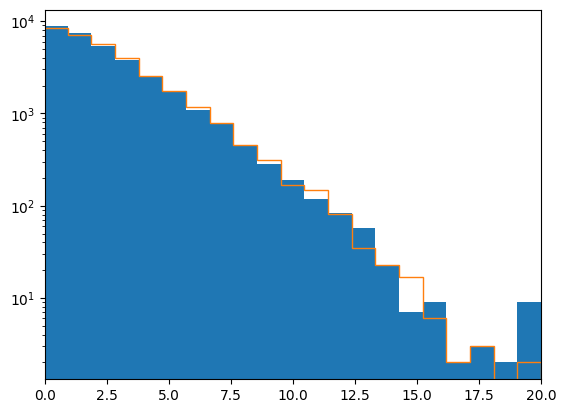

In [ ]:
# np.array(Nhalo_all_truth_concat).shape
pl.figure()
_ = pl.hist(np.array(Nhalo_all_truth_concat), range=(-1,20), bins=22)
_ = pl.hist(np.array(Nhalo_all_concat), range=(-1,20), bins=22, histtype='step')
pl.yscale('log')
pl.xlim(0,20)



In [ ]:
# len(Mhalo_all)
# len(np.array(Mhalo_all_truth_concat)), len(np.array(Mhalo_all_concat))
np.amin(np.array(Mhalo_all_truth_concat)), np.amax(np.array(Mhalo_all_concat))
                                           


(13.529777777777777, 15.404666666666666)

(13.5, 15.5)

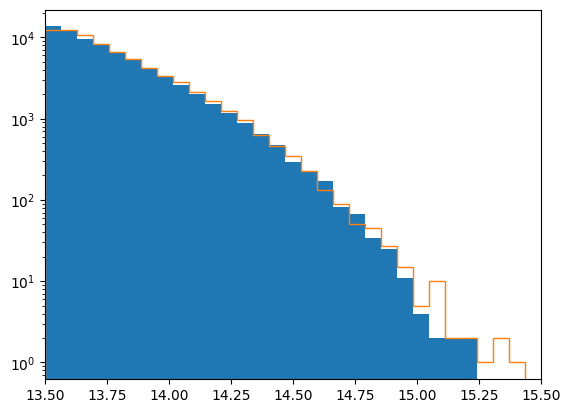

In [ ]:
# np.array(Nhalo_all_truth_concat).shape
pl.figure()
_ = pl.hist(np.array(Mhalo_all_truth_concat), range=(13.5,15.5), bins=31)
# _ = pl.hist(np.array(lgMass_truth_orig), range=(13,15.5), bins=21, histtype='step')
_ = pl.hist(np.array(Mhalo_all_concat), range=(13.5,15.5), bins=31, histtype='step')
pl.yscale('log')
pl.xlim(13.5, 15.5)
# lgMass_truth_orig


In [ ]:
# np.nonzero(Nhalo_all_truth_concat)[0].shape, np.nonzero(Nhalo_all_concat)[0].shape, pos_all_concat.shape, pos_all_truth_concat.shape

# np.nonzero(Nhalo_all_truth_concat)[0].shape, np.nonzero(Nhalo_all_concat)[0].shape


In [46]:
# import copy
# pos_all_concat_try1 = copy.deepcopy(pos_all_concat)
np.unique(np.array(Mhalo_all_truth_concat))


array([13.52977778, 13.56155556, 13.59333333, 13.62511111, 13.65688889,
       13.68866667, 13.72044444, 13.75222222, 13.784     , 13.81577778,
       13.84755556, 13.87933333, 13.91111111, 13.94288889, 13.97466667,
       14.00644444, 14.03822222, 14.07      , 14.10177778, 14.13355556,
       14.16533333, 14.19711111, 14.22888889, 14.26066667, 14.29244444,
       14.32422222, 14.356     , 14.38777778, 14.41955556, 14.45133333,
       14.48311111, 14.51488889, 14.54666667, 14.57844444, 14.61022222,
       14.642     , 14.67377778, 14.70555556, 14.73733333, 14.76911111,
       14.80088889, 14.83266667, 14.86444444, 14.89622222, 14.928     ,
       14.95977778, 14.99155556, 15.02333333, 15.05511111, 15.08688889])

In [110]:
# import copy
# pos_all_concat_try2 = copy.deepcopy(pos_all_concat)



In [111]:
# pos_all_concat_try1.shape

In [112]:
# pos_all_concat_try2


In [113]:
# # grid_Pk = 512
# grid_Pk_full = 512
# threads = 10
# MAS = 'CIC'
# mesh_mock = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
# # indsel_M = np.where((np.array(Mhalo_all_concat) > Mmin_Pk) & (np.array(Mhalo_all_concat) < Mmax_Pk))[0]
# # print(f'Number of halos in tokenized mock cat {len(indsel_M)}')
# MASL.MA(pos_all_concat_try1.astype(np.float32), mesh_mock, 1000., MAS)
# mesh_mock1 = mesh_mock/np.mean(mesh_mock, dtype=np.float64);  mesh_mock1 -= 1.0
# Pk_mock1_full = PKL.Pk(mesh_mock1, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)

# # grid_Pk = 512
# threads = 10
# MAS = 'CIC'
# mesh_mock = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
# # indsel_M = np.where((np.array(Mhalo_all_concat) > Mmin_Pk) & (np.array(Mhalo_all_concat) < Mmax_Pk))[0]
# # print(f'Number of halos in tokenized mock cat {len(indsel_M)}')
# MASL.MA(pos_all_concat_try2.astype(np.float32), mesh_mock, 1000., MAS)
# mesh_mock2 = mesh_mock/np.mean(mesh_mock, dtype=np.float64);  mesh_mock2 -= 1.0
# Pk_mock2_full = PKL.Pk(mesh_mock2, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)




# # Pk_truth_mock_full = PKL.XPk([mesh_mock, mesh_truth], 1000., axis=0, MAS=[MAS, MAS], threads=threads)




In [114]:
# pl.figure()
# pl.plot(Pk_mock1_full.k3D, Pk_mock1_full.Pk[:,0], color='r', ls='-', alpha=1.0, lw=1.0)
# pl.plot(Pk_mock2_full.k3D, Pk_mock2_full.Pk[:,0], color='b', ls='-', alpha=1.0, lw=1.0)
# pl.plot(Pk_truth_full_orig.k3D, Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0, lw=1.0)
# pl.xscale('log')
# pl.yscale('log')


In [97]:
# np.amin(pos_all_truth_concat[:,2]), np.amax(pos_all_truth_concat[:,2])
np.amin(pos_all_concat[:,2]), np.amax(pos_all_concat[:,2])
# pos_all_truth_concat.shape



(0.4652777777777777, 1000.0)

In [98]:
# pl.figure(figsize=(6,6))
# pl.scatter(pos_all_concat[:,0], pos_all_concat[:,1], s=0.001)
# pl.title('Halos Mock (tokenized)', size=16)


In [99]:
# isim_fid = 1
snapnum = 3
mass_type = 'rockstar_200c'
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
if mass_type == 'rockstar_vir':
    index_M = header.index('Mvir')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
if mass_type == 'rockstar_200c':
    index_M = header.index('M200c')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

Mmin_cut = 10**13.5
lgMass_truth = np.log10(mass_truth)
indsel = np.where(mass_truth > Mmin_cut)[0]
# print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
pos_h_truth_orig = pos_h_truth[indsel]
lgMass_truth_orig = lgMass_truth[indsel]



/tmp/ipykernel_708657/4139340561.py:20: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)


Text(0.5, 1.0, 'Halos Mock (tokenized)')

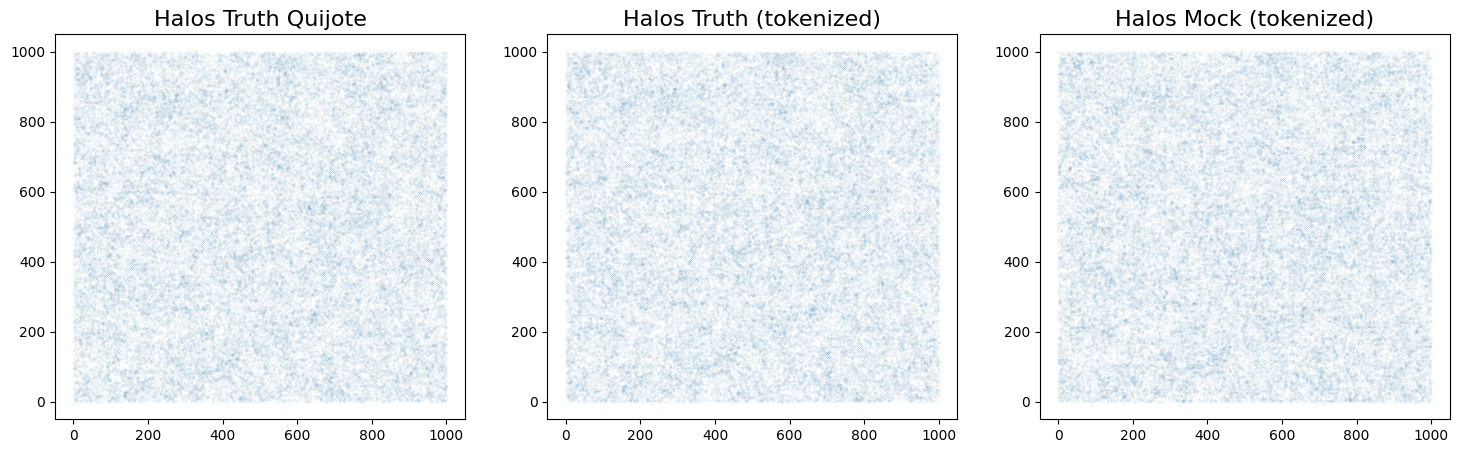

In [100]:
fig, (ax1, ax2, ax3) = pl.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('Horizontally stacked subplots')
# ax1.plot(x, y)
# ax2.plot(x, -y)

ax1.scatter(pos_h_truth_orig[:,0], pos_h_truth_orig[:,1], s=0.001)
ax1.set_title('Halos Truth Quijote', size=16)


ax2.scatter(pos_all_truth_concat[:,0], pos_all_truth_concat[:,1], s=0.001)
ax2.set_title('Halos Truth (tokenized)', size=16)


# ax1.set_xlim(400,600)
# ax1.set_ylim(400,600)
# fig.add_subplot(121)
ax3.scatter(pos_all_concat[:,0], pos_all_concat[:,1], s=0.001)
ax3.set_title('Halos Mock (tokenized)', size=16)
# ax2.set_xlim(400,600)
# ax2.set_ylim(400,600)




In [101]:
# Mmin_Pk, Mmax_Pk = 13.5, np.inf
# Mmin_Pk, Mmax_Pk = 13.478, np.inf
Mmin_Pk, Mmax_Pk = 13.5, np.inf
# Mmin_Pk, Mmax_Pk = 13.5, 14.0
# Mmin_Pk, Mmax_Pk = -np.inf, np.inf
M1 = 14.0
# alpha = 0.66
alpha = 0.6




In [102]:
grid_Pk_full = 512
threads = 10
MAS = 'CIC'
mesh_truth = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
indsel_M = np.where((lgMass_truth_orig > Mmin_Pk) & (lgMass_truth_orig < Mmax_Pk))[0]
print(f'Number of halos in original true cat {len(indsel_M)}')
W = (10**lgMass_truth_orig[indsel_M]/10**M1)**(alpha)
MASL.MA(pos_h_truth_orig[indsel_M].astype(np.float32), mesh_truth, 1000., MAS, W=W.astype(np.float32))
mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
Pk_truth_full_orig = PKL.Pk(mesh_truth, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)



Number of halos in original true cat 72627


In [103]:
# grid_Pk_full = 512
threads = 10
MAS = 'CIC'
mesh_truth = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
indsel_M = np.where((np.array(Mhalo_all_truth_concat) > Mmin_Pk) & (np.array(Mhalo_all_truth_concat) < Mmax_Pk))[0]
print(f'Number of halos in tokenized true cat {len(indsel_M)}')
W = (10**np.array(Mhalo_all_truth_concat)[indsel_M]/10**M1)**(alpha)
MASL.MA(pos_all_truth_concat[indsel_M].astype(np.float32), mesh_truth, 1000., MAS, W=W.astype(np.float32))
mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
Pk_truth_full = PKL.Pk(mesh_truth, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)




Number of halos in tokenized true cat 72619


In [104]:
# grid_Pk = 512
threads = 10
MAS = 'CIC'
mesh_mock = np.zeros((grid_Pk_full, grid_Pk_full, grid_Pk_full), dtype=np.float32)
indsel_M = np.where((np.array(Mhalo_all_concat) > Mmin_Pk) & (np.array(Mhalo_all_concat) < Mmax_Pk))[0]
print(f'Number of halos in tokenized mock cat {len(indsel_M)}')
W = (10**np.array(Mhalo_all_concat)[indsel_M]/10**M1)**(alpha)
MASL.MA(pos_all_concat[indsel_M].astype(np.float32), mesh_mock, 1000., MAS, W=W.astype(np.float32))
mesh_mock /= np.mean(mesh_mock, dtype=np.float64);  mesh_mock -= 1.0
Pk_mock_full = PKL.Pk(mesh_mock, 1000., axis=0, MAS=MAS, threads=threads, verbose=False)




Number of halos in tokenized mock cat 73967


In [105]:
np.amax(np.array(Mhalo_all_concat))


15.404666666666666

In [106]:
# isim_fid


Text(0.5, 1.0, 'Sim index = 5, 13.5$ < \\log({M}) <$inf')

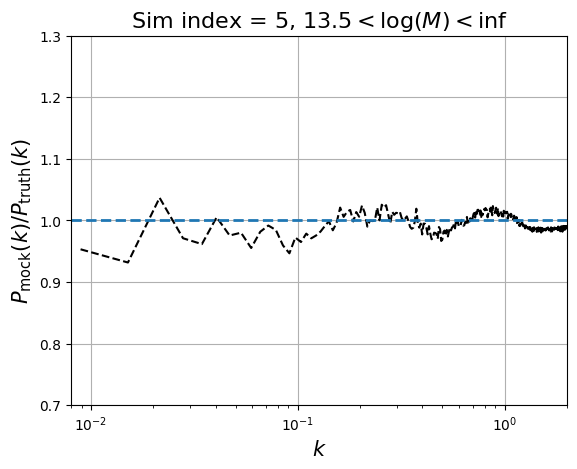

In [107]:
pl.figure()
# pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full.Pk[:,0], color='k', ls='-', alpha=1.0)
pl.plot(Pk_truth_full_orig.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='--', alpha=1.0)
# pl.plot(Pk_truth_full_orig.k3D, Pk_truth_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls=':', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_truth_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_mock.k3D, Pk_mock.Pk[:,0], color='r', ls='--', alpha=1.0)

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.7, 1.3)
pl.xlim(0.008, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.grid()
# pl.ylabel(r'$\Delta P(k)/P(k)$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)
pl.title(f'Sim index = {isim_fid}, ' + str(Mmin_Pk) + r'$ < \log({M}) <$' + str(Mmax_Pk), size=16)




In [169]:
Pk_truth_mock_full = PKL.XPk([mesh_mock, mesh_truth], 1000., axis=0, MAS=[MAS, MAS], threads=threads)



Computing power spectra of the fields...
Time FFTS = 1.05
Time loop = 2.86
Time taken = 3.92 seconds


Text(0, 0.5, '$r(k) = P_{\\rm truth \\times mock}/\\sqrt{P_{\\rm truth} \\times P_{\\rm mock}}$')

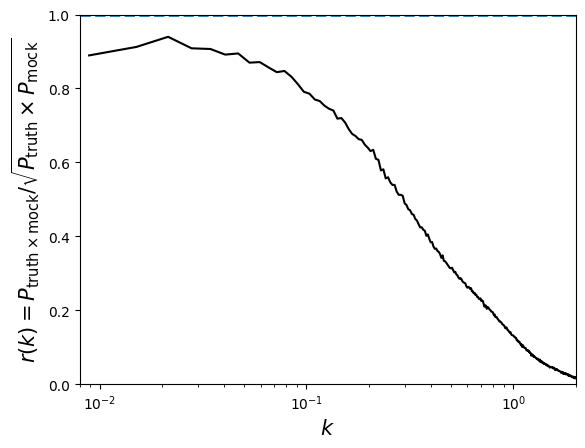

In [121]:
pl.figure()
pl.plot(Pk_truth_full.k3D, Pk_truth_mock_full.XPk[:,0,0]/np.sqrt(Pk_truth_full.Pk[:,0] * Pk_mock_full.Pk[:,0]), color='k', ls='-', alpha=1.0)
# pl.plot(Pk_mock.k3D, Pk_mock.Pk[:,0], color='r', ls='--', alpha=1.0)

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.0, 1.0)
pl.xlim(0.008, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$r(k) = P_{\rm truth \times mock}/\sqrt{P_{\rm truth} \times P_{\rm mock}}$', size=15)




Text(0.5, 1.0, '13.5$ < \\log({M}) <$14.0')

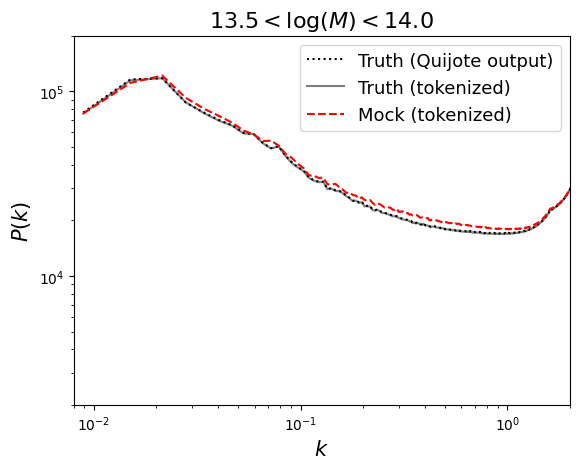

In [65]:
pl.figure()
pl.plot(Pk_truth_full.k3D, Pk_truth_full_orig.Pk[:,0], color='k', ls=':', alpha=1.0, label='Truth (Quijote output)')
pl.plot(Pk_truth_full.k3D, Pk_truth_full.Pk[:,0], color='k', ls='-', alpha=0.5, label='Truth (tokenized)')
pl.plot(Pk_mock_full.k3D, Pk_mock_full.Pk[:,0], color='r', ls='--', alpha=1.0, label='Mock (tokenized)')

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
# pl.axhline(0.0, ls='--', lw=2.0)
pl.xscale('log')
pl.yscale('log')
pl.legend(fontsize=13)
pl.ylim(2e3, 2e5)
pl.xlim(0.008, 2)

# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
pl.title(str(Mmin_Pk) + r'$ < \log({M}) <$' + str(Mmax_Pk), size=16)




Text(0.5, 1.0, '13.0$ < \\log({M}) <$13.5')

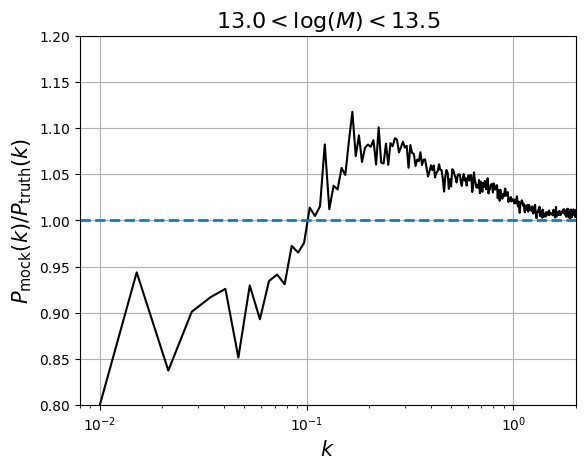

In [123]:
pl.figure()
pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_mock_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_truth_full.k3D, Pk_truth_full.Pk[:,0]/Pk_truth_full_orig.Pk[:,0], color='k', ls='-', alpha=1.0)
# pl.plot(Pk_mock.k3D, Pk_mock.Pk[:,0], color='r', ls='--', alpha=1.0)

# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(1.0, ls='--', lw=2.0)
pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.8, 1.2)
pl.xlim(0.008, 2)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.grid()
# pl.ylabel(r'$\Delta P(k)/P(k)$', size=15)
pl.ylabel(r'$P_{\rm mock}(k)/P_{\rm truth}(k)$', size=15)
pl.title(str(Mmin_Pk) + r'$ < \log({M}) <$' + str(Mmax_Pk), size=16)



In [95]:
Nhalo_all_truth_concat = []
for jv in range(len(Nhalo_all_truth)):
    if type(Nhalo_all_truth[jv]) == int:
        Nhalo_all_truth_concat.append(Nhalo_all_truth[jv])

Nhalo_all_concat = []
for jv in range(len(Nhalo_all)):
    if type(Nhalo_all[jv]) == int:
        Nhalo_all_concat.append(Nhalo_all[jv])  

    

In [96]:
# 2+2
len(Nhalo_all_concat), len(Nhalo_all_truth_concat)
# Nhalo_all_concat[0:100]
# Nhalo_all[0]


(32682, 32043)

In [97]:
# Nhalo_all_hist
# Nhalo_all_concat[0:100]
# bins_all

In [98]:
bins_all = np.linspace(0,40, 40)
bins_cents = (bins_all[:-1] + bins_all[1:])/2
Nhalo_all_hist, _ = np.histogram(np.array(Nhalo_all_concat), bins= bins_all)
Nhalo_all_truth_hist, _ = np.histogram(np.array(Nhalo_all_truth_concat), bins= bins_all)


(0.0, 32.0)

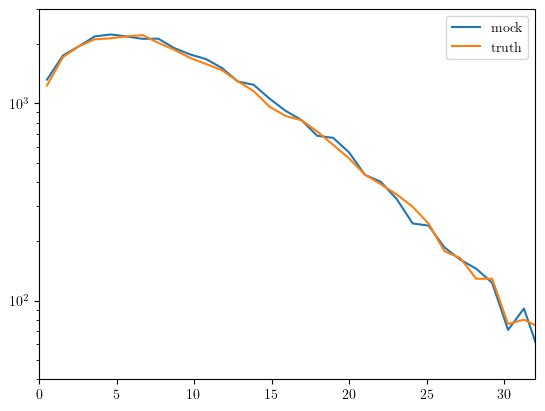

In [99]:
pl.figure()
pl.plot(bins_cents, Nhalo_all_hist, label='mock')
pl.plot(bins_cents, Nhalo_all_truth_hist, label='truth')
# _ = pl.hist(Nhalo_all_concat)
# _ = pl.hist(Nhalo_all_truth_concat)
pl.legend()
pl.yscale('log')
pl.ylim(40, 3000)
pl.xlim(0,32)




In [ ]:
pos_all_truth = []
Mhalo_all_truth = []
Nhalo_all_truth = []
# Pk_all_truth = []

BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 32
threads = 10

for jv in range(nvox_samp):
# for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        Nhalo = len(idxe) + len(idx0)
        Nhalo_all_truth.append(Nhalo)
    
        if Nhalo > 0:
            try:
                Mhalo = np.zeros(Nhalo)
                pos_halo = np.zeros((Nhalo, 3))
                for jh in range(Nhalo):
                    if jh == 0:
                        Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                        for jx in range(3):
                            pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin            
                    else:
                        if Nhalo > 2:
                            Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin            
                        else:
                            Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin            

                Mhalo_all_truth.append(Mhalo)
                pos_all_truth.append(pos_halo)

                if Nhalo > 5:
                    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                    MASL.MA(pos_halo.astype(np.float32), mesh_truth, 2*xmin, MAS)
                    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                    Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                    Pk_all_truth.append(Pk_truth.Pk[:,0])
                else:
                    Pk_all_truth.append([])

            except:
                Mhalo_all_truth.append(np.array([]))
                pos_all_truth.append(np.array([]))
                Pk_all_truth.append([])                
                pass
        else:
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])                
    else:
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])                


In [24]:
pos_all_truth = []
Mhalo_all_truth = []
Nhalo_all_truth = []
Pk_all_truth = []

BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2

MAS     = 'NGP'  #mass-assigment scheme
grid_Pk = 32
threads = 10

# for jv in range(nvox_samp):
for jv in indhigh[:nvox_samp]:    
    idx = X_val[jv]
    idx = idx.cpu().numpy().flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        Nhalo = len(idxe) + len(idx0)
        Nhalo_all_truth.append(Nhalo)
    
        if Nhalo > 0:
            try:
                Mhalo = np.zeros(Nhalo)
                pos_halo = np.zeros((Nhalo, 3))
                for jh in range(Nhalo):
                    if jh == 0:
                        Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                        for jx in range(3):
                            pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin            
                    else:
                        if Nhalo > 2:
                            Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin            
                        else:
                            Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin            

                Mhalo_all_truth.append(Mhalo)
                pos_all_truth.append(pos_halo)

                if Nhalo > 5:
                    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                    MASL.MA(pos_halo.astype(np.float32), mesh_truth, 2*xmin, MAS)
                    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                    Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                    Pk_all_truth.append(Pk_truth.Pk[:,0])
                else:
                    Pk_all_truth.append([])

            except:
                Mhalo_all_truth.append(np.array([]))
                pos_all_truth.append(np.array([]))
                Pk_all_truth.append([])                
                pass
        else:
            Mhalo_all_truth.append(np.array([]))
            pos_all_truth.append(np.array([]))
            Pk_all_truth.append([])                
    else:
        Nhalo_all_truth.append(np.array([]))
        Mhalo_all_truth.append(np.array([]))
        pos_all_truth.append(np.array([]))
        Pk_all_truth.append([])                


/tmp/ipykernel_2188932/359875854.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_2188932/359875854.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin


In [25]:
# len(Pk_all_truth)
# Pk_truth.Pk.shape, Pk_truth.k3D.shape



In [26]:
# idx_all
Nhalo_all = []
Mhalo_all = []
Pk_all = []

for jv in range(nvox_samp):
    idx = idx_all[jv]
    idx = idx.cpu().numpy().flatten()
    # idx = idx[1:]
    # idx = idx[:np.where(idx == end_token)[0][0]]
    # idx = idx.reshape(-1, 5)
    idxe = np.where(idx == space_token)[0] + 1
    idx0 = np.where(idx == start_token)[0] + 1
    # check with idx0 is a scalar or an array:
    # try:
        # temp = len(idx0)
        # print(temp)
    # except:
    if len(idx0) == 1:
        Nhalo = len(idxe) + len(idx0)
        Nhalo_all.append(Nhalo)
    
        if Nhalo > 0:
            try:
                Mhalo = np.zeros(Nhalo)
                pos_halo = np.zeros((Nhalo, 3))                
                for jh in range(Nhalo):
                    if jh == 0:
                        Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
                        for jx in range(3):
                            pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin            

                    else:
                        if Nhalo > 2:
                            Mhalo[jh] = bins_digitize[idx[idxe[jh-1]]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe[jh-1] + jx + 1]] * 2 * xmin            

                        else:
                            Mhalo[jh] = bins_digitize[idx[idxe]] * (lgMax - lgMin) + lgMin
                            for jx in range(3):
                                pos_halo[jh, jx] = bins_digitize[idx[idxe + jx + 1]] * 2 * xmin            

                Mhalo_all.append(Mhalo)

                if Nhalo > 5:
                    mesh_truth = np.zeros((grid_Pk, grid_Pk, grid_Pk), dtype=np.float32)
                    MASL.MA(pos_halo.astype(np.float32), mesh_truth, 2*xmin, MAS)
                    mesh_truth /= np.mean(mesh_truth, dtype=np.float64);  mesh_truth -= 1.0
                    Pk_truth = PKL.Pk(mesh_truth, 2*xmin, axis=0, MAS=None, threads=threads, verbose=False)
                    Pk_all.append(Pk_truth.Pk[:,0])
                else:
                    Pk_all.append([])


            except:
                Mhalo_all.append(np.array([]))
                Pk_all.append([])
                pass
        else:
            Mhalo_all.append(np.array([]))
            Pk_all.append([])

    else:
        Nhalo_all.append(np.array([]))
        Mhalo_all.append(np.array([]))
        Pk_all.append([])



/tmp/ipykernel_2188932/260296683.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Mhalo[jh] = bins_digitize[idx[idx0]] * (lgMax - lgMin) + lgMin
/tmp/ipykernel_2188932/260296683.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pos_halo[jh, jx] = bins_digitize[idx[idx0 + jx + 1]] * 2 * xmin


Text(0, 0.5, '$\\Delta P(k)/P(k)$')

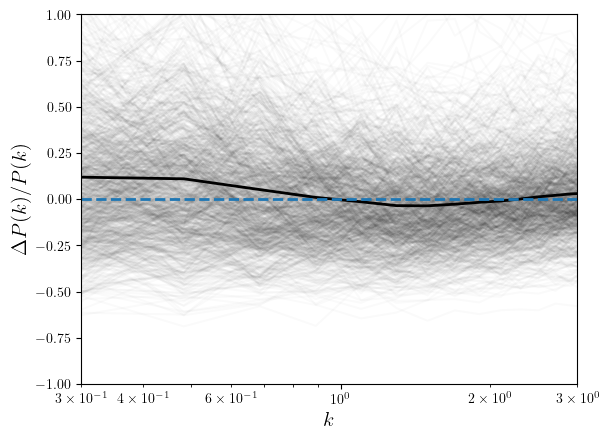

In [27]:
pl.figure()
resid_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, (Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp], color='k', ls='-', alpha=0.02)
        resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])

resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.axhline(0.0, ls='--', lw=2.0)
pl.xscale('log')
pl.ylim(-1.0, 1.0)
pl.xlim(0.3, 3)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$\Delta P(k)/P(k)$', size=15)




Text(0, 0.5, '$P(k)$')

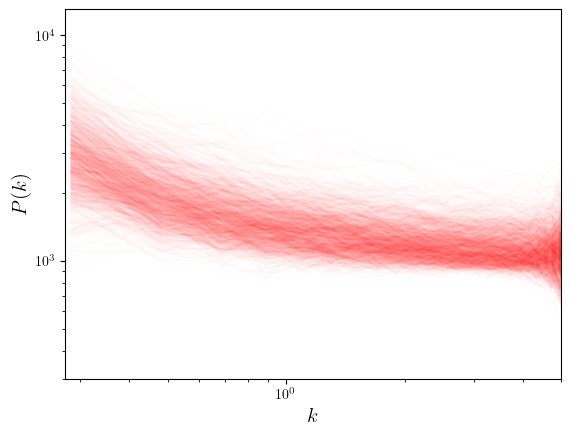

In [28]:
pl.figure()
Pktruth_mean_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='r', ls='-', alpha=0.01)
        Pktruth_mean_all.append(Pk_all_truth[jp])
        # pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='--', alpha=0.01)
        # resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])
Pktruth_mean_all = np.vstack(Pktruth_mean_all)
# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(-0.5, 0.5)
pl.xlim(0.275, 5)
pl.ylim(3e2, 1.3e4)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
# pl.title(r'Truth', size)



Text(0, 0.5, '$P(k)$')

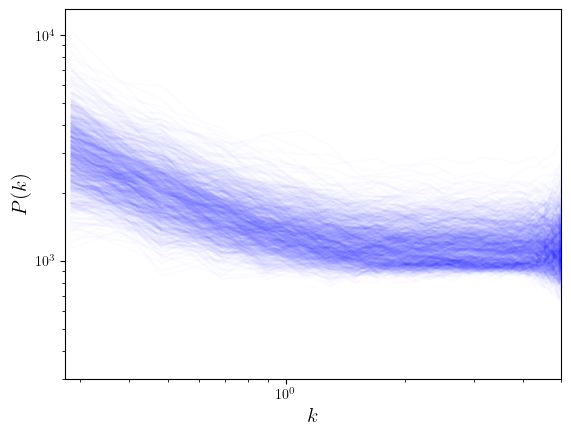

In [29]:
pl.figure()
Pk_mean_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all[jp], color='b', ls='-', alpha=0.01)
        Pk_mean_all.append(Pk_all[jp])
        # pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='--', alpha=0.01)
        # resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])
Pk_mean_all = np.vstack(Pk_mean_all)
# resid_all = np.vstack(resid_all)
# pl.plot(Pk_truth.k3D, np.mean(resid_all, axis=0), color='k', ls='-', alpha=1.0, lw=2.0)
pl.xscale('log')
pl.yscale('log')
# pl.ylim(-0.5, 0.5)
pl.xlim(0.275, 5)
pl.ylim(3e2, 1.3e4)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
# pl.title(r'Truth', size)



Text(0, 0.5, '$P(k)$')

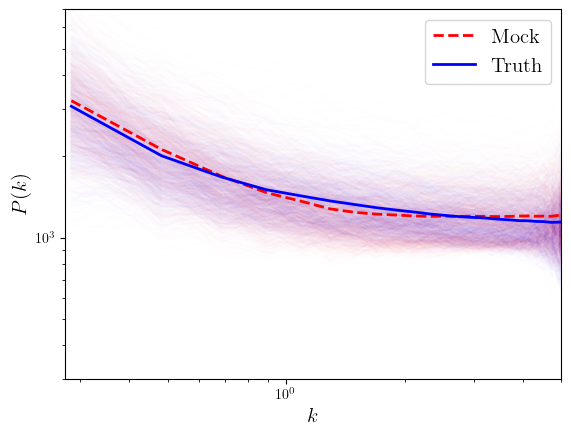

In [32]:
pl.figure()
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all[jp], color='r', ls='-', alpha=0.004)
        # Pk_mean_all.append(Pk_all[jp])

Pktruth_mean_all = []
for jp in range(len(Pk_all)):
    if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='-', alpha=0.004)
        Pktruth_mean_all.append(Pk_all_truth[jp])

# Pk_mean_all = []
# for jp in range(len(Pk_all)):
    # if (len(Pk_all[jp]) > 0) and (len(Pk_all_truth[jp]) > 0):
        # pl.plot(Pk_truth.k3D, Pk_all[jp], color='b', ls='-', alpha=0.01)
        # Pk_mean_all.append(Pk_all[jp])
        # pl.plot(Pk_truth.k3D, Pk_all_truth[jp], color='b', ls='--', alpha=0.01)
        # resid_all.append((Pk_all[jp] - Pk_all_truth[jp])/Pk_all_truth[jp])
# Pk_mean_all = np.vstack(Pk_mean_all)
# resid_all = np.vstack(resid_all)
pl.plot(Pk_truth.k3D, np.mean(Pk_mean_all, axis=0), color='r', ls='--', alpha=1.0, lw=2.0, label=r'Mock')
pl.plot(Pk_truth.k3D, np.mean(Pktruth_mean_all, axis=0), color='b', ls='-', alpha=1.0, lw=2.0, label=r'Truth')
pl.xscale('log')
pl.yscale('log')
# pl.ylim(-0.5, 0.5)
pl.xlim(0.275, 5)
pl.ylim(3e2, 7e3)
pl.legend(fontsize=15)
# pl.scale('log')
pl.xlabel(r'$k$', size=15)
pl.ylabel(r'$P(k)$', size=15)
# pl.title(r'Truth', size)



In [33]:
np.mean(Pk_mean_all, axis=0)/np.mean(Pktruth_mean_all, axis=0)


array([1.0486252 , 1.05577959, 1.00665098, 0.97575422, 0.9546787 ,
       0.93452781, 0.93591016, 0.94635405, 0.95848757, 0.96656779,
       0.97886587, 0.99196451, 1.00044523, 1.00899766, 1.0120348 ,
       1.01731845, 1.02384885, 1.03089531, 1.03986128, 1.04235678,
       1.04500534, 1.04772846, 1.05269957, 1.06006241, 1.05776604,
       1.04989725, 1.0576422 ])

In [39]:
Mhalo_all_truth_concat = []
for jv in range(len(Mhalo_all_truth)):
    Mhalo_all_truth_concat.extend(Mhalo_all_truth[jv])

Mhalo_all_concat = []
for jv in range(len(Mhalo_all)):
    Mhalo_all_concat.extend(Mhalo_all[jv])    


Text(0.5, 1.0, 'High density voxels, $\\bar{\\delta}_{{\\rm 32Mpc}/h} > 1.3$')

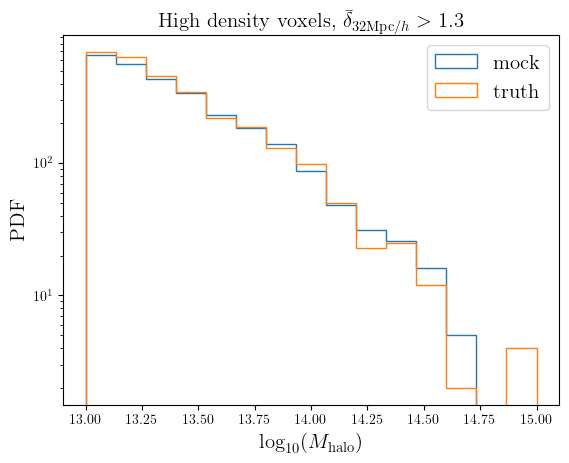

In [40]:
pl.figure()
_ = pl.hist(Mhalo_all_concat, bins=15, range=(lgMin, 15),  histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'High density voxels, $\bar{\delta}_{{\rm 32Mpc}/h} > 1.3$', size=15)






In [57]:
Mhalo_all_concat_low = []
Mhalo_all_concat_mid = []
Mhalo_all_concat_high = []
for jv in indlow:
    Mhalo_all_concat_low.extend(Mhalo_all[jv])

for jv in indmid:
    Mhalo_all_concat_mid.extend(Mhalo_all[jv])

for jv in indhigh:
    Mhalo_all_concat_high.extend(Mhalo_all[jv])
    

In [58]:
# Mhalo_all_truth_concat = []
# for jv in range(len(Mhalo_all_truth)):
    # Mhalo_all_truth_concat.extend(Mhalo_all_truth[jv])

Mhalo_all_truth_concat_low = []
Mhalo_all_truth_concat_mid = []
Mhalo_all_truth_concat_high = []

for jv in indlow:
    Mhalo_all_truth_concat_low.extend(Mhalo_all_truth[jv])

for jv in indmid:
    Mhalo_all_truth_concat_mid.extend(Mhalo_all_truth[jv])

for jv in indhigh:
    Mhalo_all_truth_concat_high.extend(Mhalo_all_truth[jv])

    



Text(0.5, 1.0, 'High density voxels, $\\bar{\\delta}_{{\\rm 32Mpc}/h} > 1.3$')

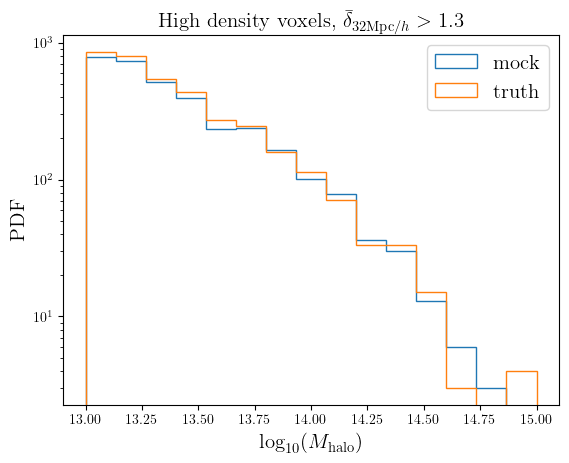

In [59]:
pl.figure()
_ = pl.hist(Mhalo_all_concat_high, bins=15, range=(lgMin, 15),  histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat_high, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'High density voxels, $\bar{\delta}_{{\rm 32Mpc}/h} > 1.3$', size=15)



Text(0.5, 1.0, 'Mid density voxels, $0.75 < \\bar{\\delta}_{{\\rm 32Mpc}/h} < 1.3$')

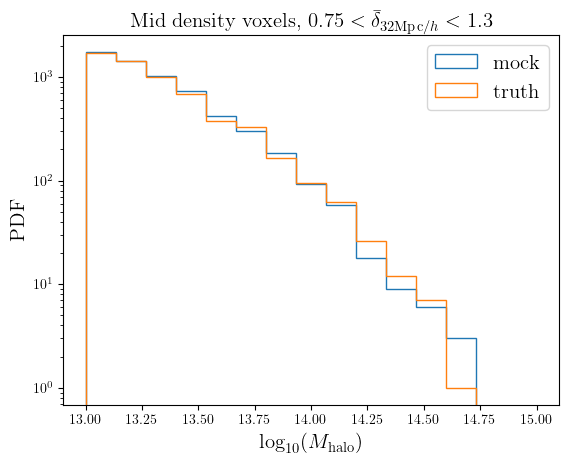

In [60]:
pl.figure()
_ = pl.hist(Mhalo_all_concat_mid, bins=15, range=(lgMin, 15), histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat_mid, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'Mid density voxels, $0.75 < \bar{\delta}_{{\rm 32Mpc}/h} < 1.3$', size=15)



Text(0.5, 1.0, 'Low density voxels, $\\bar{\\delta}_{{\\rm 32Mpc}/h} < 0.75$')

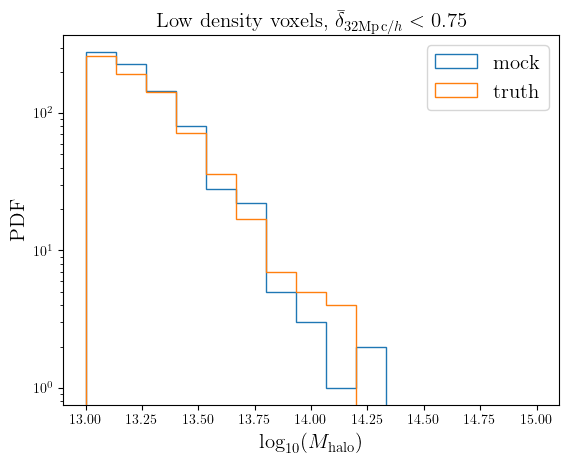

In [61]:
pl.figure()
_ = pl.hist(Mhalo_all_concat_low, bins=15, range=(lgMin, 15), histtype='step', label='mock')
# _ = pl.hist(lgMsim_truth, bins=15, range=(lgMin, 15), density=True, histtype='step', label='truth')
_ = pl.hist(Mhalo_all_truth_concat_low, bins=15, range=(lgMin, 15), histtype='step', label='truth')
pl.yscale('log')
pl.legend(fontsize=15)
pl.xlabel(r'$\log_{10}(M_{\rm halo})$', size=15)
pl.ylabel(r'PDF', size=15)
pl.title(r'Low density voxels, $\bar{\delta}_{{\rm 32Mpc}/h} < 0.75$', size=15)



In [64]:
from tqdm import tqdm
indhigh_to_plot = indhigh[::4]
idx_inp = torch.zeros((1, 1), dtype=torch.long, device=dev)
nvox_samp = len(indhigh_to_plot)
max_new_tokens = 160
end_token = 129
idx_all = []
for jv in tqdm(range(nvox_samp)):
    ind_jv = indhigh_to_plot[jv]
    DM_val_jv = DM_val[ind_jv,...]
    idx = idx_inp
    for _ in range(max_new_tokens):
        # crop idx to the last block_size tokens
        idx_cond = idx[:, -block_size:]
        # get the predictions
        logits, loss = model(idx_cond, DM_val_jv.unsqueeze(0))
        # focus only on the last time step
        logits = logits[:, -1, :] # becomes (B, C)
        # apply softmax to get probabilities
        probs = F.softmax(logits, dim=-1) # (B, C)
        # sample from the distribution
        idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
        # append sampled index to the running sequence
        if idx_next == end_token:
            break
        idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
    idx_all.append(idx)
    



(tensor([  0,  54,  53, 121, 106, 130,  41,  11,  99,  19, 130,  20,  68, 123,
         122, 130,  19,  69, 104, 119, 130,  17, 119, 121, 117, 130,   8,  77,
         100, 110, 130,   7,  70, 125,  37, 130,   6,  54, 113,  95, 130,   5,
          83, 126,   4, 130,   2,  71, 102, 119, 129,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1], device='cuda:0'),
 tensor([[  0,  60,  59, 119, 104, 130,  44,  59, 118, 109, 130,  35,  35